In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import torch, torch_geometric
# print("Torch:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# print("PyG:", torch_geometric.__version__)


In [ ]:
!pip install -q torch_geometric
!pip install -q class_resolver
!pip3 install pymatting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00


In [1]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import torch
# import util
from PIL import Image
import matplotlib.pyplot as plt
from numpy import asarray
import tifffile as tiff
import torch.nn as nn
import torch.nn.functional as nnFn
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from sklearn.manifold import TSNE
import random
from torch_geometric.nn import ARMAConv
import copy

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load MCI features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


In [ ]:
# fa_feature_path = "/content/drive/MyDrive/TejaswiAbburi_va797/Dataset/ISBI_ADNI_CN_dataset/Processed_histogram_features_CN_All/Histogram_CN_FA_20bin_updated.npy"
# Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# # Load MCI features
# fa_feature_path = "/content/drive/MyDrive/TejaswiAbburi_va797/Dataset/ISBI_ADNI_MCI_dataset/Processed_histogram_features_MCI_All/Histogram_MCI_FA_20bin_updated.npy"
# Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# # Combine features and labels
# X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
# y = np.hstack([
#     np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
#     np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
# ])
# np.random.seed(42)
# perm = np.random.permutation(X.shape[0])
# X = X[perm]
# y = y[perm]
# num_nodes, num_feats = X.shape
# print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


## 1 layer

In [3]:
def sim(h1, h2, tau = 0.2):
    z1 = nnFn.normalize(h1, dim=-1, p=2)
    z2 = nnFn.normalize(h2, dim=-1, p=2)
    return torch.mm(z1, z2.t()) / tau

def contrastive_loss_wo_cross_network(h1, h2, z):
    f = lambda x: torch.exp(x)
    intra_sim = f(sim(h1, h1))
    inter_sim = f(sim(h1, h2))
    return -torch.log(inter_sim.diag() /
                     (intra_sim.sum(dim=-1) + inter_sim.sum(dim=-1) - intra_sim.diag()))

def contrastive_loss_wo_cross_view(h1, h2, z):
    f = lambda x: torch.exp(x)
    cross_sim = f(sim(h1, z))
    return -torch.log(cross_sim.diag() / cross_sim.sum(dim=-1))

In [4]:
class MLP(nn.Module):
    def __init__(self, inp_size, outp_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.PReLU(), # nn.ELU()
            nn.Dropout(0.3),
            nn.Linear(hidden_size, outp_size)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
class ARMAEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, device, activ="ELU", num_stacks=1, num_layers=1):
        super(ARMAEncoder, self).__init__()
        self.device = device
        # Define all activation functions
        activations = {
            "SELU": nnFn.selu,
            "SiLU": nnFn.silu,
            "GELU": nnFn.gelu,
            "ELU": nnFn.elu,
            "RELU": nnFn.relu
        }
        # Get the activation function based on the input string
        self.act = activations.get(activ, nnFn.elu)

        self.arma = ARMAConv(
            in_channels=input_dim,
            out_channels=hidden_dim,
            num_stacks=num_stacks,   # number of parallel stacks
            num_layers=num_layers,   # depth per stack
            act=self.act,               # nonlinearity inside ARMA
            shared_weights=True,     # weight sharing across layers
            dropout=0.25             # ARMA-internal dropout
        )
        self.batchnorm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.mlp = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.arma(x, edge_index)
        x = self.dropout(x)
        x = self.batchnorm(x)
        logits = self.mlp(x)
        return logits

In [6]:
class EMA(): # Moving Average update

    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def update_average(self, old, new):
        # old: old model parameter
        # new: new model parameter
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

def update_moving_average(ema_updater, ma_model, current_model):
    for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
        old_weight, up_weight = ma_params.data, current_params.data
        ma_params.data = ema_updater.update_average(old_weight, up_weight)

In [7]:
class ARMA(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_clusters, device, activ, moving_average_decay=0.5, cut=True):
        super(ARMA, self).__init__()
        self.device = device
        self.num_clusters = num_clusters
        self.cut = cut
        self.beta = 0.6

        # Use ARMA encoder instead of GCN encoder
        self.online_encoder = ARMAEncoder(input_dim, hidden_dim, device, activ)
        self.target_encoder = copy.deepcopy(self.online_encoder)

        activations = {
            "SELU": nnFn.selu,
            "SiLU": nnFn.silu,
            "GELU": nnFn.gelu,
            "RELU": nnFn.relu
        }
        self.act = activations.get(activ, nnFn.elu)

        # Predictor head
        self.online_predictor = MLP(hidden_dim, num_clusters, hidden_dim)

        # Loss selection
        self.loss = self.cut_loss if cut else self.modularity_loss
        self.target_ema_updater = EMA(moving_average_decay)

    def reset_moving_average(self):
        del self.target_encoder
        self.target_encoder = None

    def update_ma(self):
        assert self.target_encoder is not None, 'target encoder has not been created yet'
        update_moving_average(self.target_ema_updater, self.target_encoder, self.online_encoder)

    def forward(self, data1, data2):
        x1 = self.online_encoder(data1)
        logits1 = self.online_predictor(x1)
        S1 = nnFn.softmax(logits1, dim=1)

        x2 = self.online_encoder(data2)
        logits2 = self.online_predictor(x2)
        S2 = nnFn.softmax(logits2, dim=1)

        with torch.no_grad():
            target_proj_one = self.target_encoder(data1).detach()
            target_proj_two = self.target_encoder(data2).detach()

        l1 = self.beta * contrastive_loss_wo_cross_network(x1, x2, target_proj_two) + \
             (1.0 - self.beta) * contrastive_loss_wo_cross_view(x1, x2, target_proj_two)

        l2 = self.beta * contrastive_loss_wo_cross_network(x2, x1, target_proj_one) + \
             (1.0 - self.beta) * contrastive_loss_wo_cross_view(x2, x1, target_proj_one)

        return S1, S2, logits1, logits2, l1, l2

    def modularity_loss(self, A, S):
        C = nnFn.softmax(S, dim=1)
        d = torch.sum(A, dim=1)
        m = torch.sum(A)
        B = A - torch.ger(d, d) / (2 * m)

        I_S = torch.eye(self.num_clusters, device=self.device)
        # k = torch.norm(I_S)
        k = torch.tensor(self.num_clusters, device=self.device, dtype=torch.float32)
        n = S.shape[0]

        modularity_term = (-1 / (2 * m)) * torch.trace(torch.mm(torch.mm(C.t(), B), C))
        collapse_reg_term = (torch.sqrt(k) / n) * torch.norm(torch.sum(C, dim=0), p='fro') - 1

        return modularity_term + collapse_reg_term

    def cut_loss(self, A, S):
        S = nnFn.softmax(S, dim=1)
        A_pool = torch.matmul(torch.matmul(A, S).t(), S)
        num = torch.trace(A_pool)

        D = torch.diag(torch.sum(A, dim=-1))
        D_pooled = torch.matmul(torch.matmul(D, S).t(), S)
        den = torch.trace(D_pooled)
        mincut_loss = -(num / den)

        St_S = torch.matmul(S.t(), S)
        I_S = torch.eye(self.num_clusters, device=self.device)
        ortho_loss = torch.norm(St_S / torch.norm(St_S) - I_S / torch.norm(I_S))

        return mincut_loss + ortho_loss

In [8]:
def create_adj(features, cut, alpha=1.0):
    """Return a dense W0 matrix (only once), as you originally used for A1 / unsup loss.
       We still create the dense matrix once, but all augmentations below work with edge_index.
    """
    F_norm = features / np.linalg.norm(features, axis=1, keepdims=True)
    W = np.dot(F_norm, F_norm.T)

    if cut == 0:
        W = np.where(W >= alpha, 1, 0).astype(np.float32)
        W = (W / W.max()).astype(np.float32)
    else:
        W = (W * (W >= alpha)).astype(np.float32)
    return W

In [10]:
def edge_index_from_dense(W):
    """Return edge_index as numpy array shape (2, E) and edge_weight vector."""
    rows, cols = np.nonzero(W > 0)
    edge_index = np.vstack([rows, cols]).astype(np.int64)
    edge_weight = W[rows, cols].astype(np.float32)
    return edge_index, edge_weight

In [9]:
def build_adj_list(edge_index_np, num_nodes):
    """Build adjacency list: list of neighbor arrays for each node (numpy)."""
    adj = [[] for _ in range(num_nodes)]
    src = edge_index_np[0]
    dst = edge_index_np[1]
    for s, d in zip(src, dst):
        adj[s].append(d)
    # convert to numpy arrays for speed
    adj = [np.array(neis, dtype=np.int64) if len(neis) > 0 else np.array([], dtype=np.int64) for neis in adj]
    return adj

In [11]:
def aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=None):
    """Randomly drop edges from edge_index. Returns new edge_index (2 x E') and edge_weight placeholder."""
    rng = np.random.default_rng(seed)
    E = edge_index_np.shape[1]
    keep_mask = rng.random(E) >= drop_percent
    new_edge_index = edge_index_np[:, keep_mask]
    return new_edge_index

In [12]:
def aug_subgraph_edge_index(features_np, edge_index_np, adj_list, drop_percent=0.2, seed=None):
    """
    Sample a subgraph by selecting s_node_num nodes via neighbor expansion (BFS-like),
    then return (sub_features, sub_edge_index) with node ids remapped to [0..s-1].
    """
    rng = np.random.default_rng(seed)
    num_nodes = features_np.shape[0]
    s_node_num = int(num_nodes * (1 - drop_percent))
    if s_node_num < 1:
        s_node_num = 1

    # choose a random center node
    center_node = int(rng.integers(0, num_nodes))
    sub_nodes = [center_node]
    front_idx = 0

    # BFS-like expansion using adjacency list until we reach s_node_num
    while len(sub_nodes) < s_node_num and front_idx < len(sub_nodes):
        cur = sub_nodes[front_idx]
        neighbors = adj_list[cur]
        if neighbors.size > 0:
            # shuffle neighbors and try to add new ones
            nbrs_shuffled = neighbors.copy()
            rng.shuffle(nbrs_shuffled)
            for nb in nbrs_shuffled:
                if nb not in sub_nodes:
                    sub_nodes.append(int(nb))
                    if len(sub_nodes) >= s_node_num:
                        break
        front_idx += 1
        # if BFS stalls (no new neighbors), add random nodes
        if front_idx >= len(sub_nodes) and len(sub_nodes) < s_node_num:
            remaining = [n for n in range(num_nodes) if n not in sub_nodes]
            if not remaining:
                break
            add = int(rng.choice(remaining))
            sub_nodes.append(add)

    sub_nodes = sorted(set(sub_nodes))
    node_map = {old: new for new, old in enumerate(sub_nodes)}

    # induce edges that have both ends in sub_nodes
    src = edge_index_np[0]
    dst = edge_index_np[1]
    mask_src_in = np.isin(src, sub_nodes)
    mask_dst_in = np.isin(dst, sub_nodes)
    mask = mask_src_in & mask_dst_in
    sel_src = src[mask]
    sel_dst = dst[mask]
    # remap
    remapped_src = np.array([node_map[int(s)] for s in sel_src], dtype=np.int64)
    remapped_dst = np.array([node_map[int(d)] for d in sel_dst], dtype=np.int64)
    new_edge_index = np.vstack([remapped_src, remapped_dst])
    # sub features
    sub_features = features_np[sub_nodes, :].astype(np.float32)
    return sub_features, new_edge_index

In [13]:
def load_data_from_edge_index(node_feats_np, edge_index_np, device):
    """Return PyG Data with torch tensors. edge_index_np is (2, E) numpy."""
    node_feats = torch.from_numpy(node_feats_np).float()
    edge_index = torch.from_numpy(edge_index_np.astype(np.int64)).long()
    return node_feats, edge_index

# Data Loading and preprocessing

In [14]:
print("CN Shape:", Histogram_feature_CN_FA_array.shape)
print("MCI Shape:",Histogram_feature_MCI_FA_array.shape)

CN Shape: (133, 180)
MCI Shape: (167, 180)


In [15]:
features = X
#features = np.concatenate((Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array), axis=0)
features = features.astype(np.float32)
print(features.shape, features.dtype)

(300, 180) float32


In [ ]:
# # Required Parameters
# cut = 0  # Consider n-cut loss OR Modularity loss
# alpha = 0.95 #0.7 # Edge creation Threshold
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# feats_dim = 180  # 20-bin
# K = 2  # Number of clusters
# epoch = [2500, 60, 100]  # Training epochs for different phases

# # Define all activation functions to test
# define_activations = ["SELU", "SiLU", "GELU", "ELU", "RELU"]
# activ = "ELU"

In [16]:
# Required Parameters
cut = 0  # Consider n-cut loss OR Modularity loss
alpha = 0.92 #0.7 # Edge creation Threshold
device = 'cuda' if torch.cuda.is_available() else 'cpu'
feats_dim = 180  # 20-bin
K = 2  # Number of clusters
epoch = [2500, 60, 100]  # Training epochs for different phases

# Define all activation functions to test
define_activations = ["SELU", "SiLU", "GELU", "ELU", "RELU"]
activ = "ELU"

In [ ]:
print(features.shape)

(300, 180)


In [ ]:
F_norm = features / np.linalg.norm(features, axis=1, keepdims=True)
W = np.dot(F_norm, F_norm.T)
print(np.array(np.nonzero(W>0.6)).shape)

(2, 89018)


In [ ]:
F_norm = features / np.linalg.norm(features, axis=1, keepdims=True)
W = np.dot(F_norm, F_norm.T)
print(W)

[[1.         0.9303693  0.93246347 ... 0.89707154 0.9144955  0.9065717 ]
 [0.9303693  0.9999997  0.93078005 ... 0.8839331  0.93771404 0.9060071 ]
 [0.93246347 0.93078005 1.         ... 0.88474894 0.9026448  0.9057702 ]
 ...
 [0.89707154 0.8839331  0.88474894 ... 0.9999998  0.8737202  0.9281509 ]
 [0.9144955  0.93771404 0.9026448  ... 0.8737202  0.9999999  0.9204371 ]
 [0.9065717  0.9060071  0.9057702  ... 0.9281509  0.9204371  1.        ]]


# Fully connected directed graph
# ONLY single directed edge between any two nodes

In [ ]:
# num_nodes = F.shape[0]
# edge_index = torch.combinations(torch.arange(num_nodes), r=2).T
# def create_adjacency_matrix(edge_index, num_nodes):
#     adj = torch.zeros((num_nodes, num_nodes))
#     adj[edge_index[0], edge_index[1]] = 1
#     return adj

# W = create_adjacency_matrix(edge_index, num_nodes).numpy()
# print("W Shape= " , W.shape)

In [17]:
W0 = create_adj(features, cut, alpha)  # shape (N, N) dense
A1 = torch.from_numpy(W0).float().to(device)

edge_index_np, edge_weight_np = edge_index_from_dense(W0)  # numpy edge_index (2, E)
num_nodes = features.shape[0]
adj_list = build_adj_list(edge_index_np, num_nodes)  # adjacency list for fast subgraph sampling

# convert features to numpy (we'll slice them in augmentations)
features_np = features.copy()

# Build initial Data object (full graph)
node_feats_full, edge_index_full = load_data_from_edge_index(features_np, edge_index_np, device)
data0 = Data(x=node_feats_full.to(device), edge_index=edge_index_full.to(device))
print("Data0:", data0)

Data0: Data(x=[300, 180], edge_index=[2, 13604])


# Model initialization

## Contrastive Loss

In [18]:
from torch.optim.lr_scheduler import StepLR
from torch.optim import AdamW
import torch.nn as nn

model = ARMA(feats_dim, 256, K, device, activ, cut=cut).to(device)
optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=0.0001)
scheduler = StepLR(optimizer, step_size=200, gamma=0.5)
criterion = nn.CrossEntropyLoss()

num_epochs = 5000
lambda_contrastive = 0.3
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
for epoch in range(num_epochs):
    # --- Augmentations using edge_index or adjacency list (fast, sparse) ---
    # 1) Random edge drop on edge_index
    W_aug1_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch)

    # 2) Subgraph via adjacency list (returns sub_features and sub_edge_index)
    W_aug2_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch + 999)
    features_aug2 = features_np.copy()

    # 3) Feature augmentations (keep these as numpy operations)
    # Feature dropout (column-wise)
    rng = np.random.default_rng(epoch)
    mask = rng.random(features_np.shape) >= 0.2
    features_aug1 = (features_np * mask.astype(np.float32))

    # Feature cell dropout (random cell zeroing)
    aug_feat2 = features_np.copy()
    num_nodes_local, feat_dim = aug_feat2.shape
    drop_feat_num = int(num_nodes_local * feat_dim * 0.2)
    # random positions to zero
    flat_idx = rng.choice(num_nodes_local * feat_dim, size=drop_feat_num, replace=False)
    rows = (flat_idx // feat_dim)
    cols = (flat_idx % feat_dim)
    aug_feat2[rows, cols] = 0.0
    features_aug2_feat = aug_feat2.astype(np.float32)

    # --- Build PyG Data objects for the two views ---
    # view1: features_aug1 with W_aug1_edge_index
    node_feats1, edge_index1 = load_data_from_edge_index(features_aug1, W_aug1_edge_index, device)
    data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

    # view2: features_aug2 (from subgraph) and its edge_index
    node_feats2, edge_index2 = load_data_from_edge_index(features_aug2, W_aug2_edge_index, device)
    data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

    # --- Training step ---
    model.train()
    optimizer.zero_grad()

    S1, S2, logits1, logits2, l1, l2 = model(data1, data2)

    unsup_loss = model.loss(A1, logits1)
    cont_loss = ((l1 + l2) / 2).mean()
    total_loss = unsup_loss + lambda_contrastive * cont_loss

    total_loss.backward()
    optimizer.step()
    scheduler.step()
    model.update_ma()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Total: {total_loss.item():.4f} | Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

Epoch 0 | Total: 1.5650 | Unsup: -0.1067 | Cont: 5.5722
Epoch 100 | Total: 1.1096 | Unsup: -0.2744 | Cont: 4.6131
Epoch 200 | Total: 1.0141 | Unsup: -0.2850 | Cont: 4.3303
Epoch 300 | Total: 0.9962 | Unsup: -0.2859 | Cont: 4.2736
Epoch 400 | Total: 0.9572 | Unsup: -0.2874 | Cont: 4.1487
Epoch 500 | Total: 0.9435 | Unsup: -0.2886 | Cont: 4.1068
Epoch 600 | Total: 0.9481 | Unsup: -0.2910 | Cont: 4.1303
Epoch 700 | Total: 0.9313 | Unsup: -0.2890 | Cont: 4.0679
Epoch 800 | Total: 0.9352 | Unsup: -0.2886 | Cont: 4.0793
Epoch 900 | Total: 0.9289 | Unsup: -0.2911 | Cont: 4.0668
Epoch 1000 | Total: 0.9233 | Unsup: -0.2881 | Cont: 4.0378
Epoch 1100 | Total: 0.9198 | Unsup: -0.2873 | Cont: 4.0236
Epoch 1200 | Total: 0.9196 | Unsup: -0.2916 | Cont: 4.0373
Epoch 1300 | Total: 0.9220 | Unsup: -0.2905 | Cont: 4.0417
Epoch 1400 | Total: 0.9175 | Unsup: -0.2908 | Cont: 4.0275
Epoch 1500 | Total: 0.9095 | Unsup: -0.2869 | Cont: 3.9882
Epoch 1600 | Total: 0.9116 | Unsup: -0.2906 | Cont: 4.0074
Epoch 170

In [ ]:
pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.



===== COMMUNITY LEVEL ANALYSIS =====

Cluster 0 distribution: Counter({0: 103, 1: 46})
Cluster 1 distribution: Counter({1: 121, 0: 30})

ROI Comparison (Cluster 0 vs Cluster 1):

Corpus Callosum (5): Cluster0=0.6762, Cluster1=0.6041, Diff=0.0721
Fornix (7): Cluster0=0.4040, Cluster1=0.3967, Diff=0.0074
Corticospinal (8): Cluster0=0.4042, Cluster1=0.3924, Diff=0.0118
Cerebral Peduncle (16): Cluster0=0.6178, Cluster1=0.5811, Diff=0.0367
Internal Capsule (18): Cluster0=0.5150, Cluster1=0.4640, Diff=0.0510
Cingulum (36): Cluster0=0.4745, Cluster1=0.3353, Diff=0.1391
Cingulum (37): Cluster0=0.4007, Cluster1=0.3295, Diff=0.0712
Cingulum (38): Cluster0=0.3828, Cluster1=0.2989, Diff=0.0839
Cingulum (39): Cluster0=0.4204, Cluster1=0.3286, Diff=0.0919

Most Important ROIs:

Cingulum (36): 0.1391
Cingulum (39): 0.0919
Cingulum (38): 0.0839
Corpus Callosum (5): 0.0721
Cingulum (37): 0.0712
Internal Capsule (18): 0.0510
Cerebral Peduncle (16): 0.0367
Corticospinal (8): 0.0118
Fornix (7): 0.0074

S

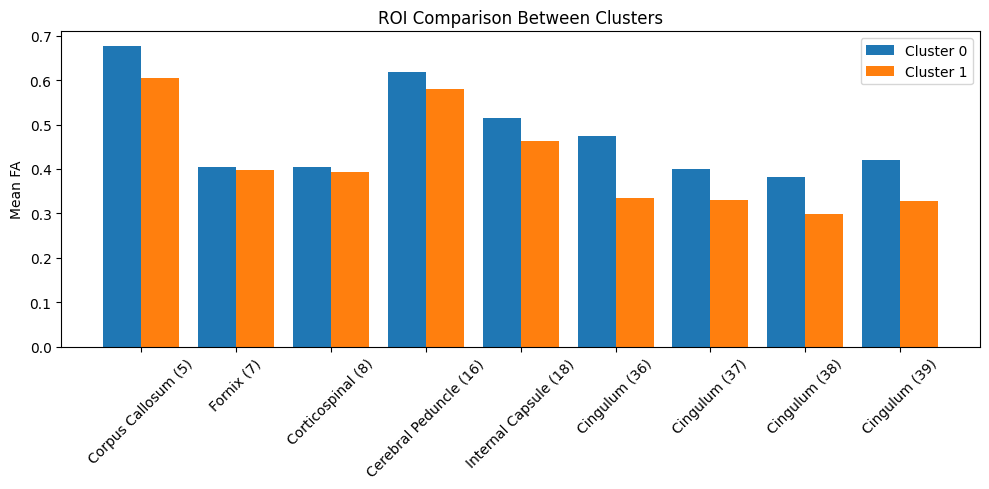

[1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1
 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1
 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0
 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0 0 1 1 0 1 1 0 1
 1 0 0 0 1 0 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1
 1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 1 1 0 0 0
 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1
 0 0 0 0]
[0.99982065 0.9988176  0.99997485 0.99948823 1.         0.99949837
 0.999943   0.6150982  0.9999951  0.9999988  0.9999995  0.9749391
 0.99989116 0.8111164  0.9999994  0.9999993  1.         0.98248637
 0.99997485 0.999995   0.96223146 0.99997604 0.99999356 0.99533695
 0.77909344 0.9931632  1.         0.95806015 0.99992585 0.9988764
 0.9704573  1.         0.9866824  0.99424875 0.99880576 0

In [19]:
from collections import Counter
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    y_pred = torch.argmax(logits1, dim=1).cpu().numpy()
    y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()

true_labels = y

print("\n===== COMMUNITY LEVEL ANALYSIS =====\n")

cluster_labels = y_pred



for k in range(2):
    idx = (cluster_labels == k)
    print(f"Cluster {k} distribution:", Counter(true_labels[idx]))


num_rois = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)",
    "Fornix (7)",
    "Corticospinal (8)",
    "Cerebral Peduncle (16)",
    "Internal Capsule (18)",
    "Cingulum (36)",
    "Cingulum (37)",
    "Cingulum (38)",
    "Cingulum (39)",
]

roi_indices = {}
for i in range(num_rois):
    roi_indices[roi_names[i]] = (i * bins_per_roi, (i + 1) * bins_per_roi)


bin_edges = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


roi_stats = {}

for roi, (start, end) in roi_indices.items():
    roi_stats[roi] = []

    for k in range(2):
        idx = (cluster_labels == k)

        roi_hist = X[idx, start:end]

        # weighted mean FA
        weighted_mean = (roi_hist * bin_centers).sum(axis=1)

        roi_stats[roi].append(weighted_mean.mean())

print("\nROI Comparison (Cluster 0 vs Cluster 1):\n")

for roi in roi_names:
    c0 = roi_stats[roi][0]
    c1 = roi_stats[roi][1]
    diff = abs(c0 - c1)

    print(f"{roi}: Cluster0={c0:.4f}, Cluster1={c1:.4f}, Diff={diff:.4f}")


roi_importance = sorted(
    [(roi, abs(vals[0] - vals[1])) for roi, vals in roi_stats.items()],
    key=lambda x: x[1],
    reverse=True
)

print("\nMost Important ROIs:\n")
for roi, diff in roi_importance:
    print(f"{roi}: {diff:.4f}")

print("\nStatistical Significance:\n")

for roi, (start, end) in roi_indices.items():

    c0_hist = X[cluster_labels == 0, start:end]
    c1_hist = X[cluster_labels == 1, start:end]

    c0_vals = (c0_hist * bin_centers).sum(axis=1)
    c1_vals = (c1_hist * bin_centers).sum(axis=1)

    stat, p = ttest_ind(c0_vals, c1_vals)

    print(f"{roi}: p-value = {p:.5f}")

roi_means_c0 = [roi_stats[roi][0] for roi in roi_names]
roi_means_c1 = [roi_stats[roi][1] for roi in roi_names]

x = np.arange(len(roi_names))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x + 0.2, roi_means_c1, width=0.4, label="Cluster 1")

plt.xticks(x, roi_names, rotation=45)
plt.ylabel("Mean FA")
plt.title("ROI Comparison Between Clusters")
plt.legend()
plt.tight_layout()
plt.show()


print(y_pred)
print(y_pred_proba.max(axis=-1))

In [20]:
acc_score = accuracy_score(y, y_pred)
acc_score_inverted = accuracy_score(y, 1 - y_pred)

print("Accuracy Score:", acc_score)
print("Accuracy Score Inverted:", acc_score_inverted)

if acc_score_inverted > acc_score:
    acc_score = acc_score_inverted
    y_pred = 1 - y_pred

prec_score = precision_score(y, y_pred)
rec_score = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
log_loss_value = log_loss(y, y_pred_proba)

print("Precision Score:", prec_score)
print("Recall Score:", rec_score)
print("F1 Score:", f1)
print("Log Loss:", log_loss_value)

Accuracy Score: 0.7466666666666667
Accuracy Score Inverted: 0.25333333333333335
Precision Score: 0.8013245033112583
Recall Score: 0.7245508982035929
F1 Score: 0.7610062893081762
Log Loss: 2.202000144180475


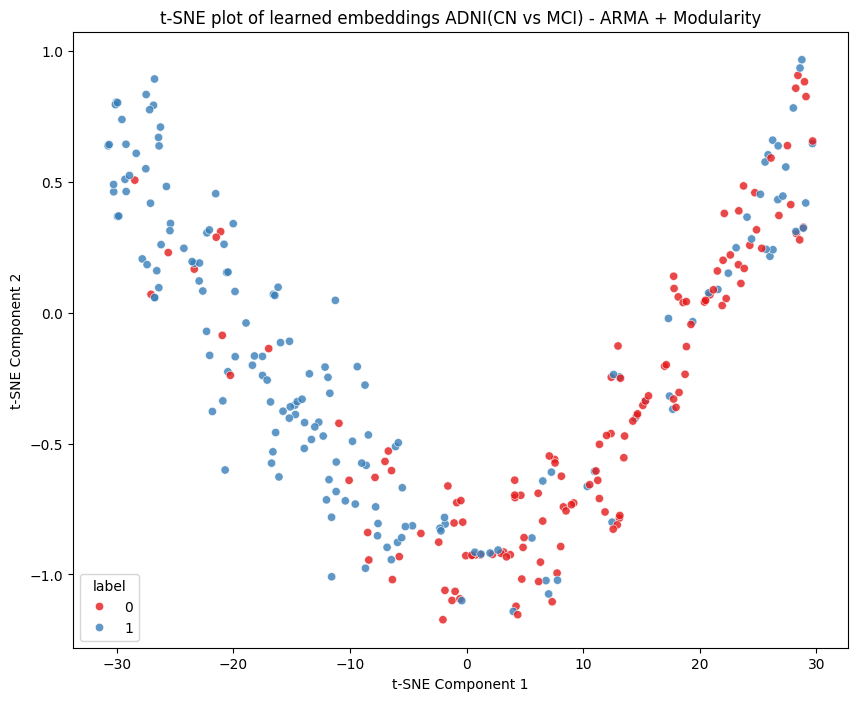

In [23]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import torch # Import torch for torch.no_grad()

# Get logits and true labels for t-SNE
model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    # Using logits1 for t-SNE visualization as it represents the output before softmax
    # and directly relates to the clustering decision.
    tsne_data = logits1.cpu().numpy()
    labels_for_plot = y # Use the true labels for coloring the t-SNE plot

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(tsne_data)

# Create a DataFrame for plotting
df_tsne = pd.DataFrame(embeddings_2d, columns=['component_1', 'component_2'])
df_tsne['label'] = labels_for_plot

# Plotting the t-SNE result
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='component_1', y='component_2', hue='label', data=df_tsne,
    palette='Set1',
    legend='full', alpha=0.8
)
plt.title('t-SNE plot of learned embeddings ADNI(CN vs MCI) - ARMA + Modularity')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ================= t-SNE ON LEARNED EMBEDDINGS =================
print("\n===== t-SNE (Predicted Clusters Only) =====\n")

model.eval()
with torch.no_grad():
    S1, logits1 = model(data0)

    embeddings = S1.cpu().numpy()
    y_pred_tsne = torch.argmax(logits1, dim=1).cpu().numpy()

# Optional label flip (for consistency)
y_true_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.array(y)
acc_n = accuracy_score(y_true_np, y_pred_tsne)
acc_i = accuracy_score(y_true_np, 1 - y_pred_tsne)
if acc_i > acc_n:
    y_pred_tsne = 1 - y_pred_tsne

# ================= t-SNE =================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

emb_2d = tsne.fit_transform(embeddings)

# ================= PLOT =================
plt.figure(figsize=(8, 6))

# 🔥 Better scientific colors
colors = ['#1f77b4', '#d62728']  # blue & red
labels = ['Cluster 0 (CN-like)', 'Cluster 1 (MCI-like)']

for k in range(2):
    idx = (y_pred_tsne == k)
    plt.scatter(
        emb_2d[idx, 0], emb_2d[idx, 1],
        c=colors[k],
        label=labels[k],
        s=45,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5
    )

# Calculate and draw a vertical split line
mean_x_cluster0 = np.mean(emb_2d[y_pred_tsne == 0, 0])
mean_x_cluster1 = np.mean(emb_2d[y_pred_tsne == 1, 0])
split_x = (mean_x_cluster0 + mean_x_cluster1) / 2
plt.axvline(x=split_x, color='gray', linestyle='--', linewidth=1.5, label=f'Split at x={split_x:.2f}')

# ================= FORMATTING =================
plt.title("t-SNE plot of learned embeddings ADNI(CN vs MCI) - ARMA + Modularity",
          fontsize=14, fontweight='bold')

plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("tsne_predicted_ADNI.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: tsne_predicted_ADNI.png")


===== t-SNE (Predicted Clusters Only) =====



TypeError: ARMA.forward() missing 1 required positional argument: 'data2'

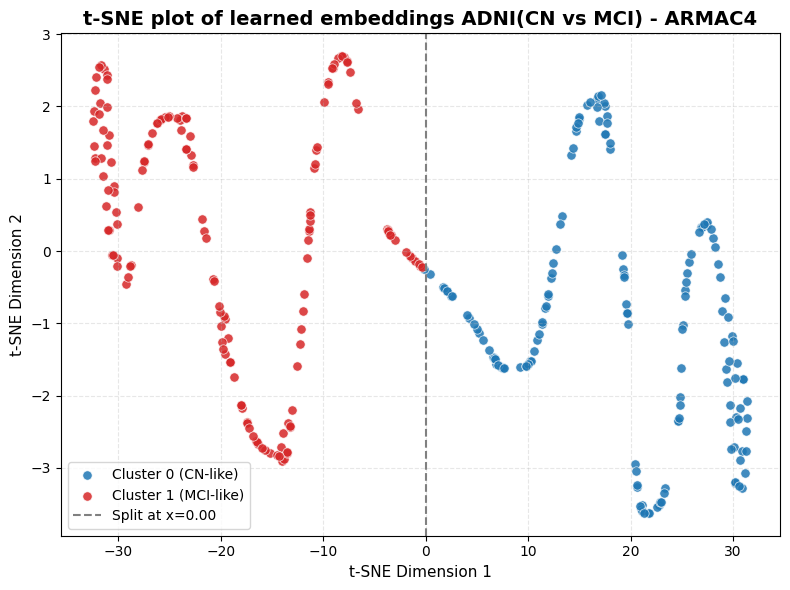

Saved: tsne_predicted_ADNI.png


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ================= t-SNE =================
# Reduce dimensionality using t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

emb_2d = tsne.fit_transform(embeddings)

# Optional label flip (for consistency)
y_true_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.array(y)
acc_n = accuracy_score(y_true_np, y_pred_tsne)
acc_i = accuracy_score(y_true_np, 1 - y_pred_tsne)
if acc_i > acc_n:
    y_pred_tsne = 1 - y_pred_tsne

# ================= PLOT =================
plt.figure(figsize=(8, 6))

# 🔥 Better scientific colors
colors = ['#1f77b4', '#d62728']  # blue & red
labels = ['Cluster 0 (CN-like)', 'Cluster 1 (MCI-like)']

for k in range(2):
    idx = (y_pred_tsne == k)
    plt.scatter(
        emb_2d[idx, 0], emb_2d[idx, 1],
        c=colors[k],
        label=labels[k],
        s=45,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5
    )

# Calculate and draw a vertical split line
mean_x_cluster0 = np.mean(emb_2d[y_pred_tsne == 0, 0])
mean_x_cluster1 = np.mean(emb_2d[y_pred_tsne == 1, 0])
split_x = (mean_x_cluster0 + mean_x_cluster1) / 2
plt.axvline(x=split_x, color='gray', linestyle='--', linewidth=1.5, label=f'Split at x={split_x:.2f}')

# ================= FORMATTING =================
plt.title("t-SNE plot of learned embeddings ADNI(CN vs MCI) - ARMAC4",
          fontsize=14, fontweight='bold')

plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("tsne_predicted_ADNI.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: tsne_predicted_ADNI.png")

In [ ]:
!pip install patsy


===== COMMUNITY LEVEL ANALYSIS =====

Cluster 0 distribution: Counter({1: 124, 0: 23})
Cluster 1 distribution: Counter({0: 110, 1: 43})

ROI Comparison (Cluster 0 vs Cluster 1):

Corpus Callosum (5): Cluster0=0.6015, Cluster1=0.6768, Diff=0.0754
Fornix (7): Cluster0=0.3970, Cluster1=0.4035, Diff=0.0065
Corticospinal (8): Cluster0=0.3927, Cluster1=0.4036, Diff=0.0109
Cerebral Peduncle (16): Cluster0=0.5796, Cluster1=0.6183, Diff=0.0387
Internal Capsule (18): Cluster0=0.4639, Cluster1=0.5137, Diff=0.0498
Cingulum (36): Cluster0=0.3335, Cluster1=0.4727, Diff=0.1392
Cingulum (37): Cluster0=0.3292, Cluster1=0.3991, Diff=0.0699
Cingulum (38): Cluster0=0.2976, Cluster1=0.3818, Diff=0.0843
Cingulum (39): Cluster0=0.3315, Cluster1=0.4152, Diff=0.0837

Most Important ROIs:

Cingulum (36): 0.1392
Cingulum (38): 0.0843
Cingulum (39): 0.0837
Corpus Callosum (5): 0.0754
Cingulum (37): 0.0699
Internal Capsule (18): 0.0498
Cerebral Peduncle (16): 0.0387
Corticospinal (8): 0.0109
Fornix (7): 0.0065

S

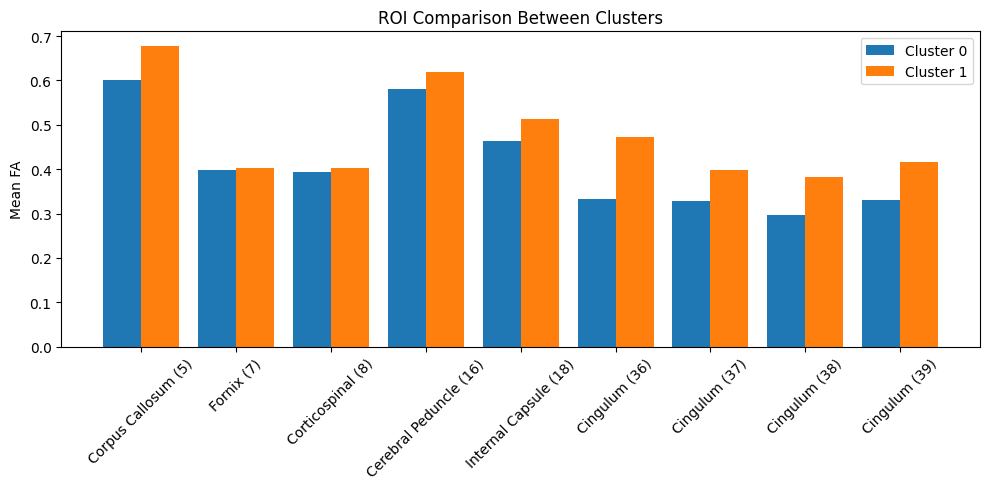

[0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0
 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 1 0 0
 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1
 1 1 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 1
 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1
 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 0
 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0
 1 1 0 1]
[0.99986756 0.99729186 0.9999112  0.9999999  1.         0.9988896
 0.9917374  0.9696088  0.9999982  1.         1.         0.9764579
 0.99988115 0.9998951  0.9999999  1.         0.99999976 0.9999974
 0.9999989  0.99999726 0.9987575  0.9999882  0.99999785 0.9986646
 0.9977779  0.999315   1.         0.500365   0.99999785 0.9999051
 0.99986565 1.         0.9817622  0.99696666 0.99982077 0.99

In [ ]:
from collections import Counter
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest  # <-- added
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    y_pred       = torch.argmax(logits1, dim=1).cpu().numpy()
    y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()

true_labels   = y
cluster_labels = y_pred

print("\n===== COMMUNITY LEVEL ANALYSIS =====\n")

for k in range(2):
    idx = (cluster_labels == k)
    print(f"Cluster {k} distribution:", Counter(true_labels[idx]))

num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)",
    "Fornix (7)",
    "Corticospinal (8)",
    "Cerebral Peduncle (16)",
    "Internal Capsule (18)",
    "Cingulum (36)",
    "Cingulum (37)",
    "Cingulum (38)",
    "Cingulum (39)",
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

roi_stats = {}
for roi, (start, end) in roi_indices.items():
    roi_stats[roi] = []
    for k in range(2):
        idx         = (cluster_labels == k)
        roi_hist    = X[idx, start:end]
        weighted_mean = (roi_hist * bin_centers).sum(axis=1)
        roi_stats[roi].append(weighted_mean.mean())

print("\nROI Comparison (Cluster 0 vs Cluster 1):\n")
for roi in roi_names:
    c0   = roi_stats[roi][0]
    c1   = roi_stats[roi][1]
    diff = abs(c0 - c1)
    print(f"{roi}: Cluster0={c0:.4f}, Cluster1={c1:.4f}, Diff={diff:.4f}")

roi_importance = sorted(
    [(roi, abs(vals[0] - vals[1])) for roi, vals in roi_stats.items()],
    key=lambda x: x[1], reverse=True
)

print("\nMost Important ROIs:\n")
for roi, diff in roi_importance:
    print(f"{roi}: {diff:.4f}")

# ================= T-TEST =================
print("\nStatistical Significance (T-test):\n")
for roi, (start, end) in roi_indices.items():
    c0_vals = (X[cluster_labels == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X[cluster_labels == 1, start:end] * bin_centers).sum(axis=1)
    stat, p = ttest_ind(c0_vals, c1_vals)
    print(f"{roi}: t-stat={stat:.4f} | p-value={p:.5f}")

# ================= 2-SAMPLE Z-TEST =================
print("\nStatistical Significance (2-Sample Z-test):\n")
print(f"{'ROI':<30} | {'Z-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)

for roi, (start, end) in roi_indices.items():
    c0_vals = (X[cluster_labels == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X[cluster_labels == 1, start:end] * bin_centers).sum(axis=1)

    # 2-sample z-test (usevar='unequal' handles different variances)
    z_stat, p_val = ztest(c0_vals, c1_vals, value=0)

    significant = "Yes ✓" if p_val < 0.05 else "No"
    print(f"{roi:<30} | {z_stat:>10.4f} | {p_val:>10.5f} | {significant:>12}")

# ================= BAR PLOT =================
roi_means_c0 = [roi_stats[roi][0] for roi in roi_names]
roi_means_c1 = [roi_stats[roi][1] for roi in roi_names]

x = np.arange(len(roi_names))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x + 0.2, roi_means_c1, width=0.4, label="Cluster 1")
plt.xticks(x, roi_names, rotation=45)
plt.ylabel("Mean FA")
plt.title("ROI Comparison Between Clusters")
plt.legend()
plt.tight_layout()
plt.show()

print(y_pred)
print(y_pred_proba.max(axis=-1))

Saved: roi_stats.csv
                   ROI  Mean_C0  Mean_C1   Diff  T_stat   T_pval  T_sig  Z_stat   Z_pval  Z_sig  U_stat   U_pval  U_sig
   Corpus Callosum (5)   0.6697   0.6093 0.0605  8.1714 0.000000   True  8.1714 0.000000   True 19832.0 0.000000   True
            Fornix (7)   0.4035   0.3971 0.0064  1.2740 0.203665  False  1.2740 0.202672  False 12223.0 0.194532  False
     Corticospinal (8)   0.4035   0.3929 0.0106  2.5471 0.011365   True  2.5471 0.010863   True 12867.0 0.031193   True
Cerebral Peduncle (16)   0.6160   0.5823 0.0337  7.0985 0.000000   True  7.0985 0.000000   True 17691.0 0.000000   True
 Internal Capsule (18)   0.5141   0.4638 0.0503 13.7088 0.000000   True 13.7088 0.000000   True 19939.0 0.000000   True
         Cingulum (36)   0.4732   0.3338 0.1394 20.3926 0.000000   True 20.3926 0.000000   True 21530.0 0.000000   True
         Cingulum (37)   0.4000   0.3288 0.0711 15.8231 0.000000   True 15.8231 0.000000   True 20616.5 0.000000   True
         Cingulum (

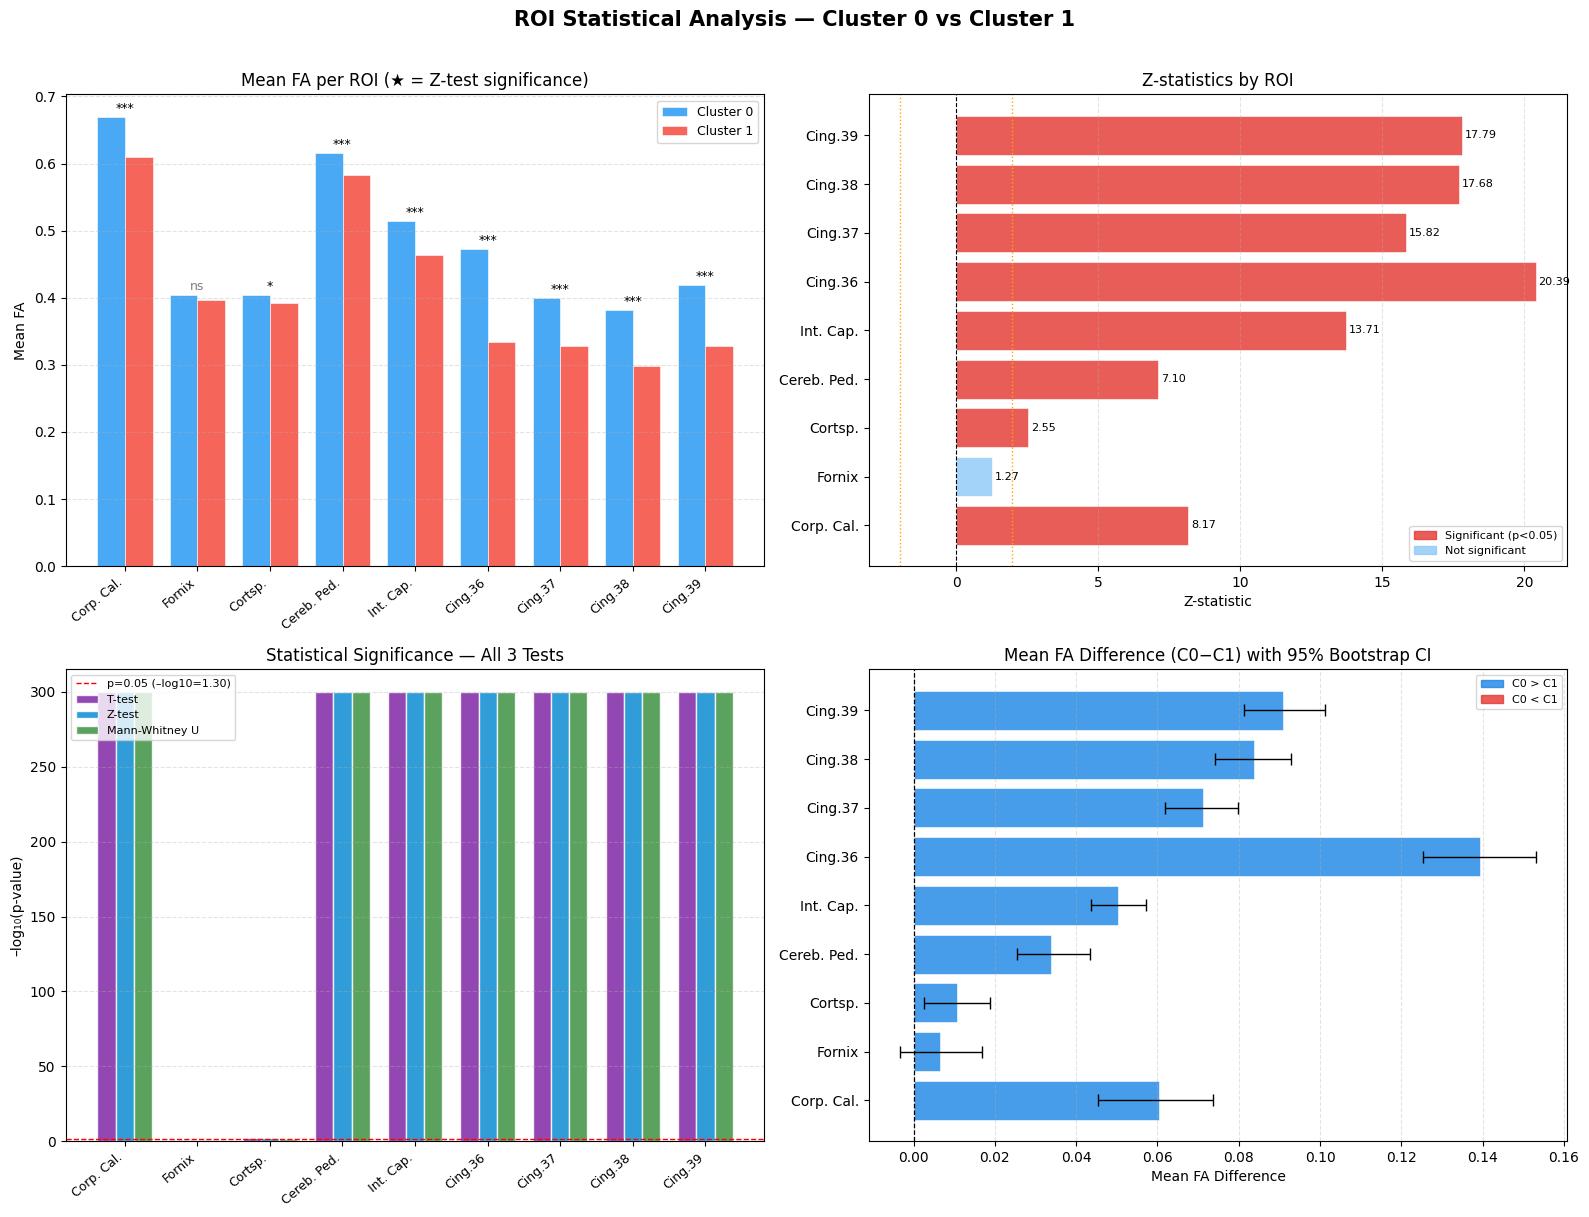

Saved: roi_combined_stats.png


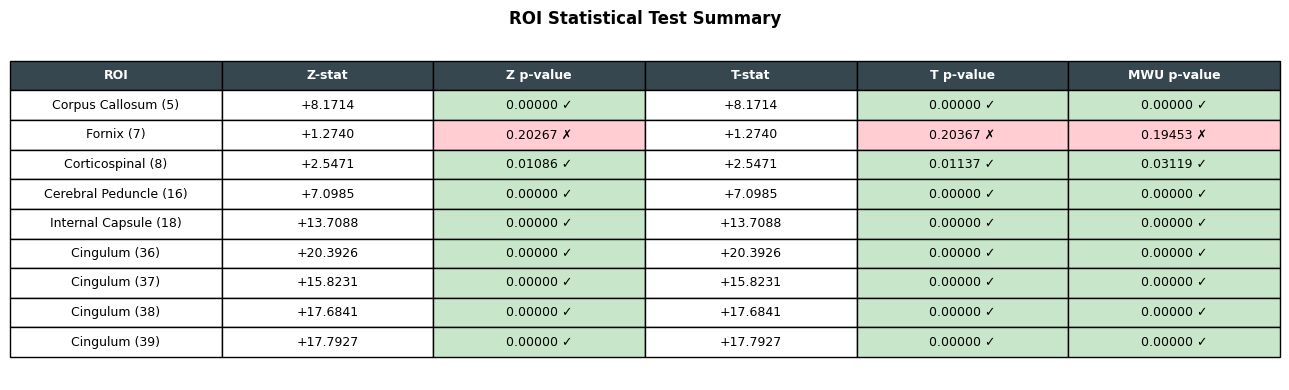

Saved: roi_pvalue_table.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest

model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    y_pred       = torch.argmax(logits1, dim=1).cpu().numpy()
    y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()

true_labels   = y
cluster_labels = y_pred

# ════════════════════════════════════════════════════════════════════
#  COMPUTE ALL STATS
# ════════════════════════════════════════════════════════════════════
num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)",
    "Fornix (7)",
    "Corticospinal (8)",
    "Cerebral Peduncle (16)",
    "Internal Capsule (18)",
    "Cingulum (36)",
    "Cingulum (37)",
    "Cingulum (38)",
    "Cingulum (39)",
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

records = []

for roi, (start, end) in roi_indices.items():
    c0_vals = (X[cluster_labels == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X[cluster_labels == 1, start:end] * bin_centers).sum(axis=1)

    # means & diff
    mean_c0 = c0_vals.mean()
    mean_c1 = c1_vals.mean()
    diff    = mean_c0 - mean_c1          # signed diff (keeps direction)

    # T-test
    t_stat, t_pval = ttest_ind(c0_vals, c1_vals)

    # Z-test
    z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)

    # Mann-Whitney U (non-parametric bonus)
    u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

    records.append({
        "ROI":       roi,
        "Mean_C0":   round(mean_c0, 4),
        "Mean_C1":   round(mean_c1, 4),
        "Diff":      round(diff, 4),
        "T_stat":    round(t_stat, 4),
        "T_pval":    round(t_pval, 6),
        "T_sig":     t_pval < 0.05,
        "Z_stat":    round(z_stat, 4),
        "Z_pval":    round(z_pval, 6),
        "Z_sig":     z_pval < 0.05,
        "U_stat":    round(u_stat, 4),
        "U_pval":    round(u_pval, 6),
        "U_sig":     u_pval < 0.05,
    })

df = pd.DataFrame(records)

# ── Save CSV ──────────────────────────────────────────────────────
df.to_csv("roi_stats.csv", index=False)
print("Saved: roi_stats.csv")
print(df.to_string(index=False))

# ════════════════════════════════════════════════════════════════════
#  COMBINED FIGURE  (4 panels)
# ════════════════════════════════════════════════════════════════════
short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

x      = np.arange(len(roi_names))
width  = 0.38
alpha  = 0.82

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "ROI Statistical Analysis — Cluster 0 vs Cluster 1",
    fontsize=15, fontweight='bold', y=1.01
)

# ── Panel 1 : Mean FA bar chart ───────────────────────────────────
ax = axes[0, 0]
bars0 = ax.bar(x - width/2, df["Mean_C0"], width, label="Cluster 0",
               color="#2196F3", alpha=alpha, edgecolor='white', linewidth=0.5)
bars1 = ax.bar(x + width/2, df["Mean_C1"], width, label="Cluster 1",
               color="#F44336", alpha=alpha, edgecolor='white', linewidth=0.5)

# significance stars above bars
for i, row in df.iterrows():
    stars = "***" if row["Z_pval"] < 0.001 else ("**" if row["Z_pval"] < 0.01 else ("*" if row["Z_pval"] < 0.05 else "ns"))
    ymax  = max(row["Mean_C0"], row["Mean_C1"]) + 0.003
    ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=9,
            color='black' if stars != "ns" else 'gray')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("Mean FA")
ax.set_title("Mean FA per ROI (★ = Z-test significance)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 2 : Z-statistics ────────────────────────────────────────
ax = axes[0, 1]
colors_z = ["#E53935" if s else "#90CAF9" for s in df["Z_sig"]]
bars = ax.barh(short_names, df["Z_stat"], color=colors_z,
               edgecolor='white', linewidth=0.5, alpha=alpha)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(-1.96, color='orange', linewidth=1, linestyle=':', label='±1.96 threshold')
ax.axvline( 1.96, color='orange', linewidth=1, linestyle=':')

for bar, val in zip(bars, df["Z_stat"]):
    ax.text(val - 0.3 if val < 0 else val + 0.1,
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va='center', ha='right' if val < 0 else 'left', fontsize=8)

sig_patch   = mpatches.Patch(color='#E53935', alpha=alpha, label='Significant (p<0.05)')
unsig_patch = mpatches.Patch(color='#90CAF9', alpha=alpha, label='Not significant')
ax.legend(handles=[sig_patch, unsig_patch], fontsize=8, loc='lower right')
ax.set_title("Z-statistics by ROI")
ax.set_xlabel("Z-statistic")
ax.grid(axis='x', linestyle='--', alpha=0.35)

# ── Panel 3 : –log10(p-value) for all 3 tests ────────────────────
ax = axes[1, 0]
log_t = -np.log10(df["T_pval"].clip(lower=1e-300))
log_z = -np.log10(df["Z_pval"].clip(lower=1e-300))
log_u = -np.log10(df["U_pval"].clip(lower=1e-300))

w3 = 0.25
ax.bar(x - w3,   log_t, w3, label="T-test",       color="#7B1FA2", alpha=alpha, edgecolor='white')
ax.bar(x,        log_z, w3, label="Z-test",        color="#0288D1", alpha=alpha, edgecolor='white')
ax.bar(x + w3,   log_u, w3, label="Mann-Whitney U", color="#388E3C", alpha=alpha, edgecolor='white')

threshold_line = -np.log10(0.05)
ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1,
           label=f'p=0.05 (–log10={threshold_line:.2f})')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("–log₁₀(p-value)")
ax.set_title("Statistical Significance — All 3 Tests")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 4 : Signed mean difference + CI ────────────────────────
ax = axes[1, 1]

# bootstrap 95% CI for mean difference
np.random.seed(42)
ci_low, ci_high = [], []
for roi, (start, end) in roi_indices.items():
    c0v = (X[cluster_labels == 0, start:end] * bin_centers).sum(axis=1)
    c1v = (X[cluster_labels == 1, start:end] * bin_centers).sum(axis=1)
    boot_diffs = [
        np.random.choice(c0v, len(c0v), replace=True).mean() -
        np.random.choice(c1v, len(c1v), replace=True).mean()
        for _ in range(1000)
    ]
    ci_low.append(np.percentile(boot_diffs, 2.5))
    ci_high.append(np.percentile(boot_diffs, 97.5))

diffs    = df["Diff"].values
err_low  = diffs - np.array(ci_low)
err_high = np.array(ci_high) - diffs
colors_d = ["#E53935" if d < 0 else "#1E88E5" for d in diffs]

ax.barh(short_names, diffs,
        xerr=[err_low, err_high],
        color=colors_d, alpha=alpha,
        edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor='black', capsize=4, linewidth=1))
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title("Mean FA Difference (C0−C1) with 95% Bootstrap CI")
ax.set_xlabel("Mean FA Difference")
ax.grid(axis='x', linestyle='--', alpha=0.35)

pos_patch = mpatches.Patch(color='#1E88E5', alpha=alpha, label='C0 > C1')
neg_patch = mpatches.Patch(color='#E53935', alpha=alpha, label='C0 < C1')
ax.legend(handles=[pos_patch, neg_patch], fontsize=8)

plt.tight_layout()
plt.savefig("roi_combined_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roi_combined_stats.png")

# ════════════════════════════════════════════════════════════════════
#  SAVE P-VALUE SUMMARY TABLE AS IMAGE
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis('off')

table_data = []
for _, row in df.iterrows():
    def fmt(pval, sig):
        s = "✓" if sig else "✗"
        return f"{pval:.5f} {s}"
    table_data.append([
        row["ROI"],
        f"{row['Z_stat']:+.4f}",
        fmt(row["Z_pval"], row["Z_sig"]),
        f"{row['T_stat']:+.4f}",
        fmt(row["T_pval"], row["T_sig"]),
        fmt(row["U_pval"], row["U_sig"]),
    ])

col_labels = ["ROI", "Z-stat", "Z p-value", "T-stat", "T p-value", "MWU p-value"]
tbl = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# colour significant cells green, non-significant red
sig_cols = [2, 4, 5]   # Z pval, T pval, MWU pval columns
for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif col_idx in sig_cols:
        txt = cell.get_text().get_text()
        if '✓' in txt:
            cell.set_facecolor('#C8E6C9')
        else:
            cell.set_facecolor('#FFCDD2')

ax2.set_title("ROI Statistical Test Summary", fontsize=12,
              fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig("roi_pvalue_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roi_pvalue_table.png")

In [ ]:
import os
print(os.getcwd())

/home/snu


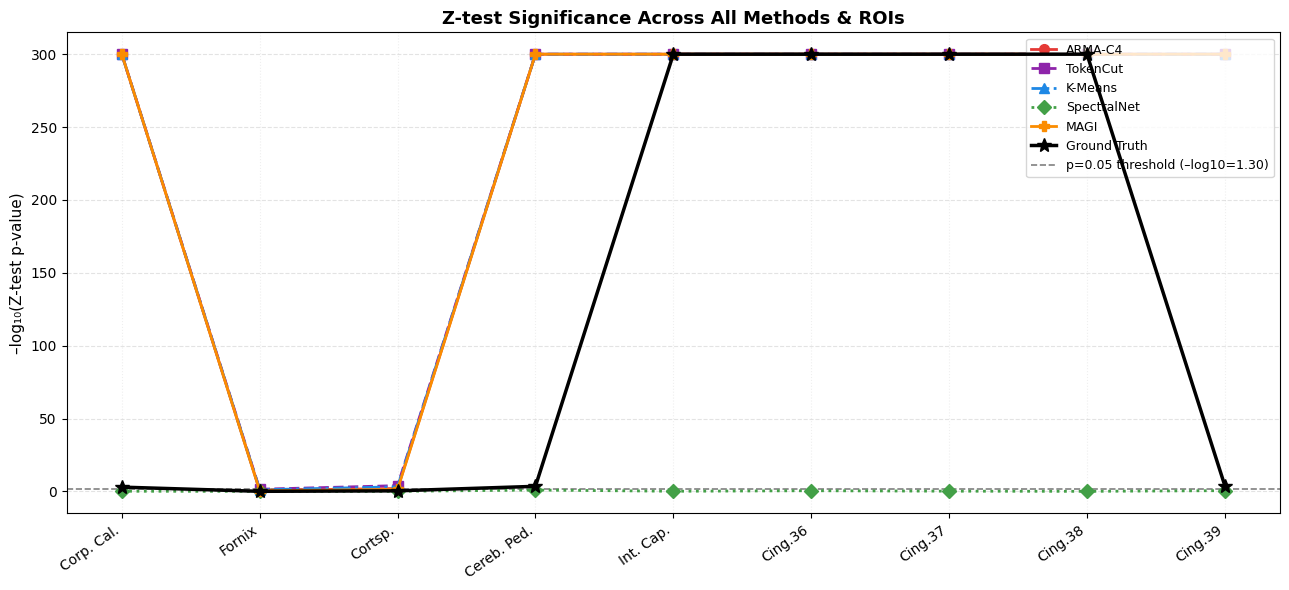

Saved: all_methods_ztest_lineplot.png


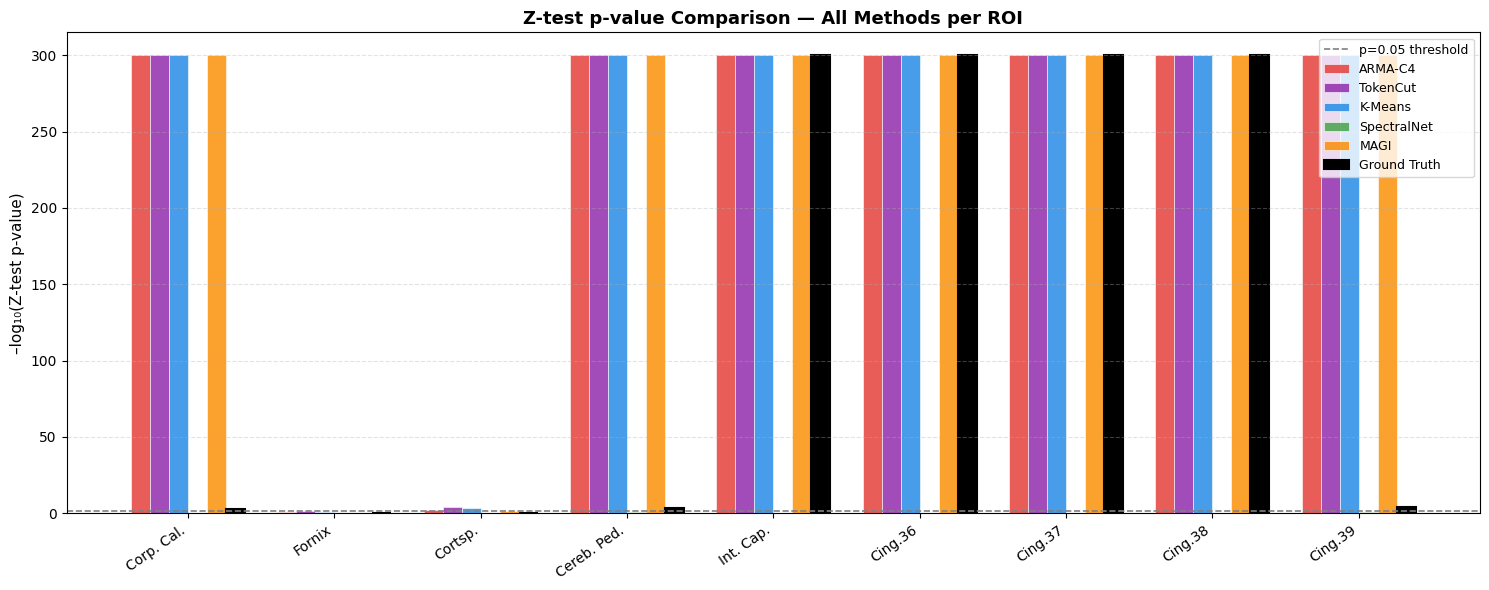

Saved: all_methods_ztest_grouped_bar.png


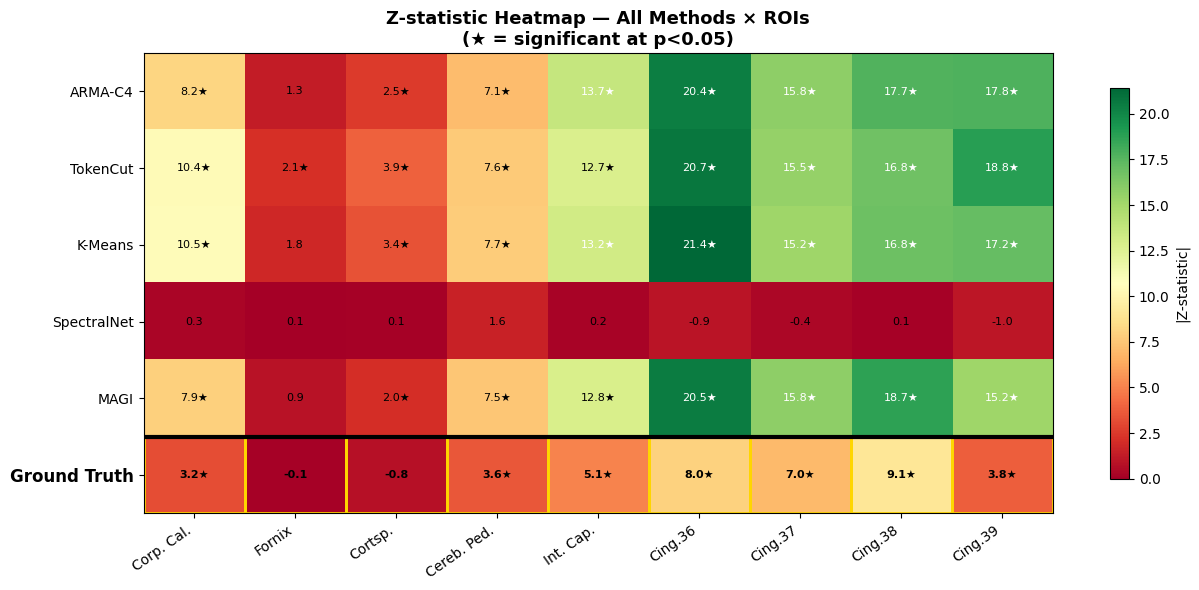

Saved: all_methods_zstat_heatmap.png


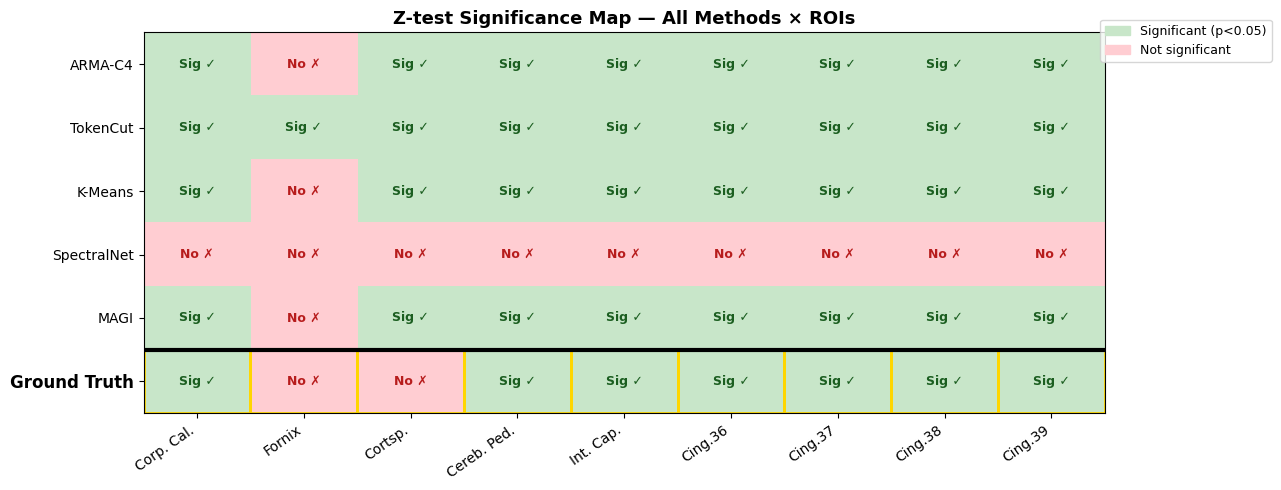

Saved: all_methods_significance_map.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ════════════════════════════════════════════════════════════════════
#  LOAD ALL SAVED CSVs  (including Ground Truth)
# ════════════════════════════════════════════════════════════════════
base = "/home/snu/Downloads/"

dfs = {
    "ARMA-C4":      pd.read_csv(base + "roi_stats.csv"),
    "TokenCut":     pd.read_csv(base + "tokencut_roi_stats.csv"),
    "K-Means":      pd.read_csv(base + "kmeans_roi_stats.csv"),
    "SpectralNet":  pd.read_csv(base + "spectral_roi_stats.csv"),
    "MAGI":         pd.read_csv(base + "magi_roi_stats.csv"),
    "Ground Truth": pd.read_csv(base + "groundtruth_roi_stats.csv"),
}

short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

# ════════════════════════════════════════════════════════════════════
#  COLOR + STYLE PER METHOD
# ════════════════════════════════════════════════════════════════════
method_styles = {
    "ARMA-C4":      {"color": "#E53935", "marker": "o", "ls": "-"},
    "TokenCut":     {"color": "#8E24AA", "marker": "s", "ls": "--"},
    "K-Means":      {"color": "#1E88E5", "marker": "^", "ls": "-."},
    "SpectralNet":  {"color": "#43A047", "marker": "D", "ls": ":"},
    "MAGI":         {"color": "#FB8C00", "marker": "P", "ls": "-"},
    "Ground Truth": {"color": "#000000", "marker": "*", "ls": "-"},
}

x     = np.arange(len(short_names))
n_met = len(dfs)

# ════════════════════════════════════════════════════════════════════
#  FIGURE 1 — –log10(Z p-value) LINE PLOT
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

for method, df in dfs.items():
    log_z = -np.log10(df["Z_pval"].clip(lower=1e-300).values)
    sty   = method_styles[method]
    lw    = 2.5 if method == "Ground Truth" else 2
    ms    = 10  if method == "Ground Truth" else 7
    ax.plot(x, log_z,
            color=sty["color"], marker=sty["marker"],
            linestyle=sty["ls"], linewidth=lw, markersize=ms,
            label=method,
            zorder=10 if method == "Ground Truth" else 5)

threshold = -np.log10(0.05)
ax.axhline(threshold, color='gray', linestyle='--', linewidth=1.2,
           label=f'p=0.05 threshold (–log10={threshold:.2f})')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax.set_ylabel("–log₁₀(Z-test p-value)", fontsize=11)
ax.set_title("Z-test Significance Across All Methods & ROIs",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.savefig(base + "all_methods_ztest_lineplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_methods_ztest_lineplot.png")

# ════════════════════════════════════════════════════════════════════
#  FIGURE 2 — GROUPED BAR  –log10(Z p-value) per ROI
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(15, 6))

bar_w   = 0.13
offsets = np.linspace(-(n_met - 1) / 2 * bar_w, (n_met - 1) / 2 * bar_w, n_met)

for i, (method, df) in enumerate(dfs.items()):
    log_z   = -np.log10(df["Z_pval"].clip(lower=1e-300).values)
    sty     = method_styles[method]
    edgecol = 'black' if method == "Ground Truth" else 'white'
    edgelw  = 1.5     if method == "Ground Truth" else 0.5
    alpha   = 1.0     if method == "Ground Truth" else 0.82
    ax.bar(x + offsets[i], log_z, bar_w,
           label=method, color=sty["color"], alpha=alpha,
           edgecolor=edgecol, linewidth=edgelw)

ax.axhline(threshold, color='gray', linestyle='--', linewidth=1.2,
           label='p=0.05 threshold')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax.set_ylabel("–log₁₀(Z-test p-value)", fontsize=11)
ax.set_title("Z-test p-value Comparison — All Methods per ROI",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(base + "all_methods_ztest_grouped_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_methods_ztest_grouped_bar.png")

# ════════════════════════════════════════════════════════════════════
#  FIGURE 3 — HEATMAP  |Z-stat|  (methods × ROIs)
#  FIX: Ground Truth row uses abs values — no negatives in color scale
#       Separate color scale for GT row using a border highlight
# ════════════════════════════════════════════════════════════════════
# Build raw matrices
z_matrix     = np.array([dfs[m]["Z_stat"].values for m in dfs])   # (6, 9)
p_matrix     = np.array([dfs[m]["Z_pval"].values for m in dfs])   # (6, 9)
method_names = list(dfs.keys())
gt_row_idx   = method_names.index("Ground Truth")

n_rows = len(method_names)
n_cols = len(short_names)

# ── KEY FIX: use abs for ALL rows including Ground Truth ──────────
z_abs = np.abs(z_matrix)

# Separate vmax for methods vs GT so GT colors are meaningful
methods_vmax = z_abs[:gt_row_idx, :].max()   # max of non-GT rows (~21)
gt_vmax      = z_abs[gt_row_idx,  :].max()   # max of GT row (~9)

# Use methods_vmax for shared scale (honest comparison)
global_vmax = methods_vmax

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(z_abs, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=global_vmax)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("|Z-statistic|", fontsize=10)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(method_names, fontsize=10)

# Bold + larger Ground Truth y-tick label
for label in ax.get_yticklabels():
    if label.get_text() == "Ground Truth":
        label.set_fontweight('bold')
        label.set_fontsize(12)

ax.set_title("Z-statistic Heatmap — All Methods × ROIs\n"
             "(★ = significant at p<0.05)",
             fontsize=13, fontweight='bold')

# Thick black separator above Ground Truth row
ax.axhline(gt_row_idx - 0.5, color='black', linewidth=3.0)

# Draw gold border around entire Ground Truth row
for j in range(n_cols):
    rect = plt.Rectangle(
        (j - 0.5, gt_row_idx - 0.5), 1, 1,
        linewidth=2, edgecolor='#FFD600', facecolor='none'
    )
    ax.add_patch(rect)

# Annotate cells — show original signed Z value + star
for i in range(n_rows):
    for j in range(n_cols):
        z_val  = z_matrix[i, j]          # original (signed) for display
        z_disp = z_abs[i, j]             # abs for color threshold
        p_val  = p_matrix[i, j]
        star   = "★" if p_val < 0.05 else ""

        # text color: white on dark green cells, black elsewhere
        txt_color = 'white' if z_disp > global_vmax * 0.6 else 'black'

        ax.text(j, i, f"{z_val:.1f}{star}",
                ha='center', va='center', fontsize=8,
                fontweight='bold' if i == gt_row_idx else 'normal',
                color=txt_color)

plt.tight_layout()
plt.savefig(base + "all_methods_zstat_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_methods_zstat_heatmap.png")

# ════════════════════════════════════════════════════════════════════
#  FIGURE 4 — SIGNIFICANCE BINARY HEATMAP  (significant yes/no)
# ════════════════════════════════════════════════════════════════════
sig_matrix = (p_matrix < 0.05).astype(float)

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(sig_matrix, aspect='auto',
               cmap=plt.matplotlib.colors.ListedColormap(['#FFCDD2', '#C8E6C9']),
               vmin=0, vmax=1)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(method_names, fontsize=10)

# Bold Ground Truth label
for label in ax.get_yticklabels():
    if label.get_text() == "Ground Truth":
        label.set_fontweight('bold')
        label.set_fontsize(12)

ax.set_title("Z-test Significance Map — All Methods × ROIs",
             fontsize=13, fontweight='bold')

# Thick separator + gold border on Ground Truth row
ax.axhline(gt_row_idx - 0.5, color='black', linewidth=3.0)
for j in range(n_cols):
    rect = plt.Rectangle(
        (j - 0.5, gt_row_idx - 0.5), 1, 1,
        linewidth=2, edgecolor='#FFD600', facecolor='none'
    )
    ax.add_patch(rect)

for i in range(n_rows):
    for j in range(n_cols):
        label = "Sig ✓" if sig_matrix[i, j] else "No ✗"
        color = "#1B5E20" if sig_matrix[i, j] else "#B71C1C"
        ax.text(j, i, label, ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

sig_patch   = mpatches.Patch(color='#C8E6C9', label='Significant (p<0.05)')
unsig_patch = mpatches.Patch(color='#FFCDD2', label='Not significant')
ax.legend(handles=[sig_patch, unsig_patch], fontsize=9,
          loc='upper right', bbox_to_anchor=(1.18, 1.05))

plt.tight_layout()
plt.savefig(base + "all_methods_significance_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_methods_significance_map.png")

In [ ]:
# Align clusters using ground truth
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, cluster_labels)
acc_inv = accuracy_score(y, 1 - cluster_labels)

if acc_inv > acc:
    cluster_labels = 1 - cluster_labels

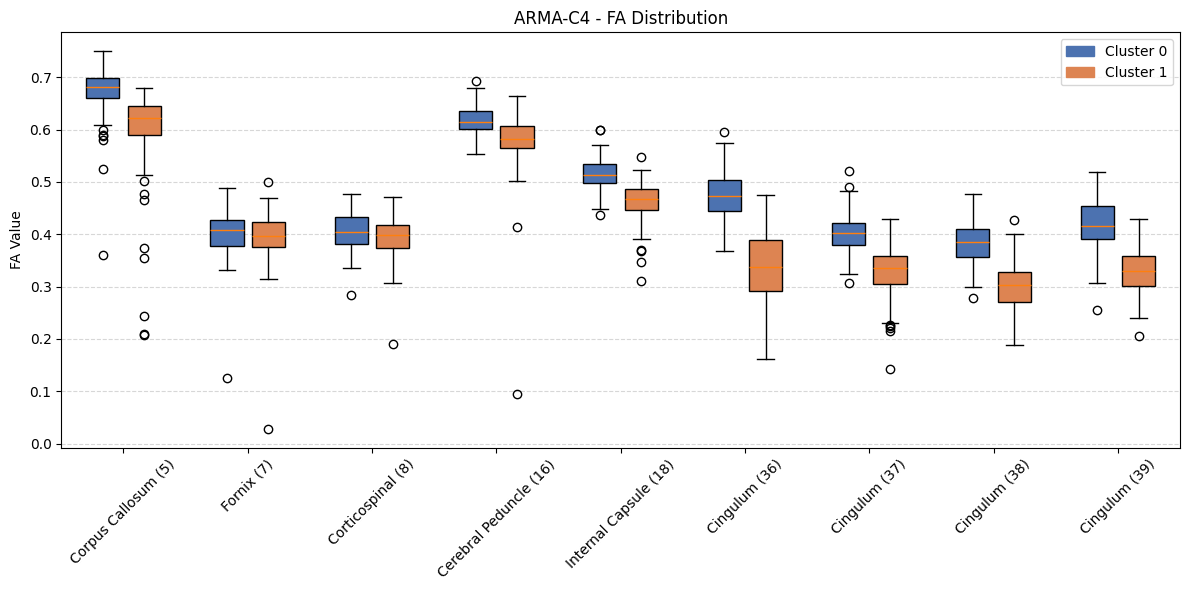

In [ ]:
color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12,6))

positions = []
data = []
colors = []

gap = 1.5
width = 0.5

for i, (roi, (start,end)) in enumerate(roi_indices.items()):

    # IMPORTANT: use ARMA predictions here
    c0 = (X[cluster_labels == 0, start:end] * bin_centers).sum(axis=1)
    c1 = (X[cluster_labels == 1, start:end] * bin_centers).sum(axis=1)

    pos0 = i * gap
    pos1 = i * gap + width

    positions += [pos0, pos1]
    data += [c0, c1]
    colors += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)

# apply same colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# xticks
xticks = [i * gap + width / 2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45)

plt.ylabel("FA Value")
plt.title("ARMA-C4 - FA Distribution")

# legend SAME as KMeans
plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color=color_c0),
        plt.Rectangle((0,0),1,1,color=color_c1)
    ],
    labels=["Cluster 0","Cluster 1"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest

# ════════════════════════════════════════════════════════════════════
#  GROUND TRUTH ROI STATS  (uses true labels y, same as ARMA-C4)
# ════════════════════════════════════════════════════════════════════

# true_labels = y  (0 = CN, 1 = MCI)
true_labels = y

records_gt = []

for roi, (start, end) in roi_indices.items():

    # Weighted mean FA per subject — exact same as ARMA-C4
    c0_vals = (X[true_labels == 0, start:end] * bin_centers).sum(axis=1)  # CN
    c1_vals = (X[true_labels == 1, start:end] * bin_centers).sum(axis=1)  # MCI

    # Means & signed diff  (CN - MCI, same direction as ARMA-C4)
    mean_c0 = c0_vals.mean()
    mean_c1 = c1_vals.mean()
    diff    = mean_c0 - mean_c1   # signed: positive = CN > MCI

    # T-test
    t_stat, t_pval = ttest_ind(c0_vals, c1_vals)

    # Z-test  (same function as ARMA-C4)
    z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)

    # Mann-Whitney U
    u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

    records_gt.append({
        "ROI":     roi,
        "Mean_C0": round(mean_c0, 4),
        "Mean_C1": round(mean_c1, 4),
        "Diff":    round(diff, 4),
        "T_stat":  round(t_stat, 4),
        "T_pval":  round(t_pval, 6),
        "T_sig":   t_pval < 0.05,
        "Z_stat":  round(z_stat, 4),
        "Z_pval":  round(z_pval, 6),
        "Z_sig":   z_pval < 0.05,
        "U_stat":  round(u_stat, 4),
        "U_pval":  round(u_pval, 6),
        "U_sig":   u_pval < 0.05,
    })

gt_df = pd.DataFrame(records_gt)

# ── Save CSV ───────────────────────────────────────────────────────
base = "/home/snu/Downloads/"
gt_df.to_csv(base + "groundtruth_roi_stats.csv", index=False)

print("Saved: groundtruth_roi_stats.csv")
print(gt_df.to_string(index=False))

Saved: groundtruth_roi_stats.csv
                   ROI  Mean_C0  Mean_C1    Diff  T_stat   T_pval  T_sig  Z_stat   Z_pval  Z_sig  U_stat   U_pval  U_sig
   Corpus Callosum (5)   0.6545   0.6282  0.0263  3.2440 0.001312   True  3.2440 0.001178   True 14517.0 0.000005   True
            Fornix (7)   0.3999   0.4006 -0.0007 -0.1339 0.893540  False -0.1339 0.893450  False 10423.0 0.360870  False
     Corticospinal (8)   0.3964   0.3998 -0.0034 -0.8102 0.418498  False -0.8102 0.417851  False 10293.5 0.276946  False
Cerebral Peduncle (16)   0.6094   0.5913  0.0181  3.5867 0.000391   True  3.5867 0.000335   True 14433.0 0.000008   True
 Internal Capsule (18)   0.5021   0.4791  0.0229  5.0679 0.000001   True  5.0679 0.000000   True 15066.0 0.000000   True
         Cingulum (36)   0.4474   0.3703  0.0771  7.9766 0.000000   True  7.9766 0.000000   True 16567.0 0.000000   True
         Cingulum (37)   0.3871   0.3472  0.0399  7.0141 0.000000   True  7.0141 0.000000   True 16018.0 0.000000   True

In [ ]:
print("\n===== GROUND TRUTH ROI ANALYSIS (CN vs MCI) =====\n")

roi_stats_gt = {}

for roi, (start, end) in roi_indices.items():

    cn_hist = X[y == 0, start:end]
    mci_hist = X[y == 1, start:end]

    cn_vals = (cn_hist * bin_centers).sum(axis=1)
    mci_vals = (mci_hist * bin_centers).sum(axis=1)

    mean_cn = cn_vals.mean()
    mean_mci = mci_vals.mean()

    diff = abs(mean_cn - mean_mci)

    roi_stats_gt[roi] = (mean_cn, mean_mci, diff)

    print(f"{roi}: CN={mean_cn:.4f}, MCI={mean_mci:.4f}, Diff={diff:.4f}")


===== GROUND TRUTH ROI ANALYSIS (CN vs MCI) =====

Corpus Callosum (5): CN=0.6545, MCI=0.6282, Diff=0.0263
Fornix (7): CN=0.3999, MCI=0.4006, Diff=0.0007
Corticospinal (8): CN=0.3964, MCI=0.3998, Diff=0.0034
Cerebral Peduncle (16): CN=0.6094, MCI=0.5913, Diff=0.0181
Internal Capsule (18): CN=0.5021, MCI=0.4791, Diff=0.0229
Cingulum (36): CN=0.4474, MCI=0.3703, Diff=0.0771
Cingulum (37): CN=0.3871, MCI=0.3472, Diff=0.0399
Cingulum (38): CN=0.3712, MCI=0.3161, Diff=0.0550
Cingulum (39): CN=0.3896, MCI=0.3620, Diff=0.0276


In [ ]:
roi_importance_gt = sorted(
    [(roi, vals[2]) for roi, vals in roi_stats_gt.items()],
    key=lambda x: x[1],
    reverse=True
)

print("\nMost Important ROIs (Ground Truth):\n")
for roi, diff in roi_importance_gt:
    print(f"{roi}: {diff:.4f}")


Most Important ROIs (Ground Truth):

Cingulum (36): 0.0771
Cingulum (38): 0.0550
Cingulum (37): 0.0399
Cingulum (39): 0.0276
Corpus Callosum (5): 0.0263
Internal Capsule (18): 0.0229
Cerebral Peduncle (16): 0.0181
Corticospinal (8): 0.0034
Fornix (7): 0.0007


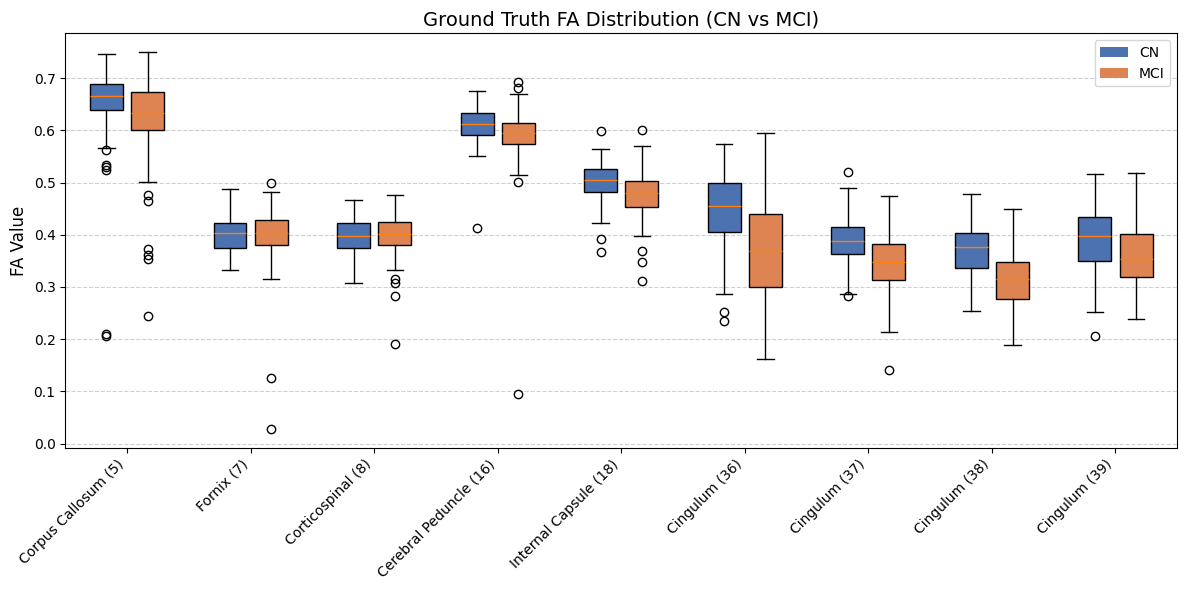

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Colors
color_cn = "#4C72B0"
color_mci = "#DD8452"

plt.figure(figsize=(12,6))

positions = []
data = []
colors = []

gap = 1.5  # spacing between ROIs
width = 0.5

for i, (roi, (start, end)) in enumerate(roi_indices.items()):

    cn_vals = (X[y==0, start:end] * bin_centers).sum(axis=1)
    mci_vals = (X[y==1, start:end] * bin_centers).sum(axis=1)

    pos_cn = i * gap
    pos_mci = i * gap + width

    positions.extend([pos_cn, pos_mci])
    data.extend([cn_vals, mci_vals])
    colors.extend([color_cn, color_mci])


box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)

# Color boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)


roi_names = list(roi_indices.keys())
xticks = [i * gap + width/2 for i in range(len(roi_names))]

plt.xticks(xticks, roi_names, rotation=45, ha='right')

# Labels
plt.ylabel("FA Value", fontsize=12)
plt.title("Ground Truth FA Distribution (CN vs MCI)", fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_cn, label='CN'),
    Patch(facecolor=color_mci, label='MCI')
]
plt.legend(handles=legend_elements)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [35]:
# -------- GET MODEL FEATURES --------
with torch.no_grad():
    embeddings = model.online_encoder(data0)   # THIS is x1
    embeddings = embeddings.cpu().numpy()

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z = pca.fit_transform(embeddings)

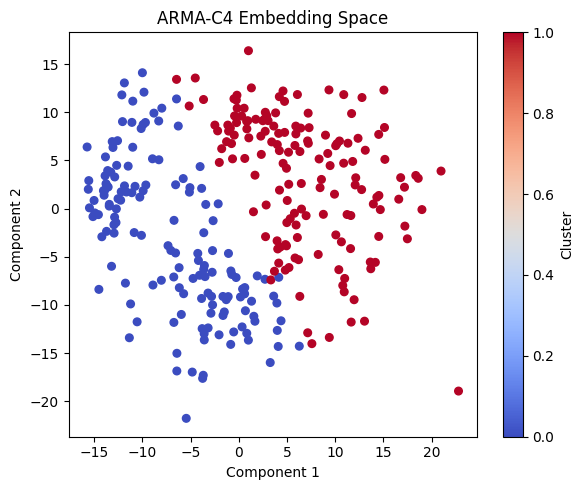

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y_pred, cmap='coolwarm', s=30)

plt.title("ARMA-C4 Embedding Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as nnFn
from torch.optim.lr_scheduler import StepLR
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)
from torch_geometric.data import Data
import random
import scipy.sparse as sp
from copy import deepcopy
from typing import Dict, List

num_runs = 10
num_epochs = 5000
lr = 1e-4
weight_decay = 1e-4
lambda_list = [0.3]
base_seed = 42
eval_every_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_acc = -1
best_y_pred = None

all_results: List[Dict] = []

for lam in lambda_list:
    print(f"\n================ LAMBDA = {lam} ================\n")

    acc_scores:  List[float] = []
    prec_scores: List[float] = []
    rec_scores:  List[float] = []
    f1_scores:   List[float] = []
    log_losses:  List[float] = []
    nmi_scores:  List[float] = []

    for run in range(num_runs):

        seed = base_seed + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        print(f"\n--- Run {run+1}/{num_runs} (seed={seed}) ---")

        model = ARMA(feats_dim, 256, K, device, activ, cut).to(device)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = StepLR(optimizer, step_size=200, gamma=0.5)
        lambda_contrastive = lam

        # ── per-run accumulators (trajectory average, for all metrics except NMI) ──
        per_run_accs:       List[float] = []
        per_run_precs:      List[float] = []
        per_run_recs:       List[float] = []
        per_run_f1s:        List[float] = []
        per_run_log_losses: List[float] = []

        # ── NMI: only keep the last eval, not a running average ──
        last_nmi: float = float('nan')

        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()

            W_aug1_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch)
            W_aug2_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch + 999)

            rng = np.random.default_rng(seed + epoch)
            mask = rng.random(features_np.shape) >= 0.2
            features_aug1 = (features_np * mask.astype(np.float32))

            aug_feat2 = features_np.copy()
            num_nodes_local, feat_dim = aug_feat2.shape
            drop_feat_num = int(num_nodes_local * feat_dim * 0.2)
            if drop_feat_num > 0:
                flat_idx = rng.choice(num_nodes_local * feat_dim, size=drop_feat_num, replace=False)
                rows = flat_idx // feat_dim
                cols = flat_idx % feat_dim
                aug_feat2[rows, cols] = 0.0
            features_aug2 = aug_feat2.astype(np.float32)

            node_feats1, edge_index1 = load_data_from_edge_index(features_aug1, W_aug1_edge_index, device)
            data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

            node_feats2, edge_index2 = load_data_from_edge_index(features_aug2, W_aug2_edge_index, device)
            data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

            S1, S2, logits1, logits2, l1, l2 = model(data1, data2)

            unsup_loss = model.loss(A1, logits1)
            cont_loss  = 0.5 * (l1 + l2).mean()
            total_loss = unsup_loss + lambda_contrastive * cont_loss

            total_loss.backward()
            optimizer.step()
            scheduler.step()

            if hasattr(model, "update_ma"):
                model.update_ma()

            if (eval_every_epochs is not None and epoch % eval_every_epochs == 0) or (epoch == num_epochs - 1):
                print(f"Epoch {epoch} | Total: {total_loss.item():.4f} | Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

                if 'data0' in globals():
                    model.eval()
                    with torch.no_grad():
                        S1_eval, _, logits_eval, _, _, _ = model(data0, data0)
                        y_pred       = torch.argmax(logits_eval, dim=1).cpu().numpy()
                        y_pred_proba = nnFn.softmax(logits_eval, dim=1).cpu().numpy()
                        y_true       = y.cpu().numpy() if isinstance(y, torch.Tensor) else y

                        acc_score          = accuracy_score(y_true, y_pred)
                        acc_score_inverted = accuracy_score(y_true, 1 - y_pred)

                        if acc_score_inverted > acc_score:
                            acc_score = acc_score_inverted
                            y_pred    = 1 - y_pred

                        if acc_score > best_acc:
                            best_acc    = acc_score
                            best_y_pred = y_pred.copy()

                        prec_score = precision_score(y_true, y_pred, zero_division=0)
                        rec_score  = recall_score(y_true, y_pred, zero_division=0)
                        f1         = f1_score(y_true, y_pred, zero_division=0)

                        try:
                            log_loss_value = log_loss(y_true, y_pred_proba)
                        except ValueError:
                            log_loss_value = float("nan")

                        # ── NMI: overwrite each eval, only last value survives ──
                        last_nmi = normalized_mutual_info_score(
                            y_true, y_pred, average_method='arithmetic'
                        )

                        per_run_accs.append(acc_score)
                        per_run_precs.append(prec_score)
                        per_run_recs.append(rec_score)
                        per_run_f1s.append(f1)
                        per_run_log_losses.append(log_loss_value)
                        # ← no per_run_nmis.append() here

        # ── fallback: if no eval triggered inside the loop ──
        if len(per_run_accs) == 0 and 'data0' in globals():
            model.eval()
            with torch.no_grad():
                S1_eval, _, logits_eval, _, _, _ = model(data0, data0)
                y_pred       = torch.argmax(logits_eval, dim=1).cpu().numpy()
                y_pred_proba = nnFn.softmax(logits_eval, dim=1).cpu().numpy()
                y_true       = y.cpu().numpy() if isinstance(y, torch.Tensor) else y

                acc_score          = accuracy_score(y_true, y_pred)
                acc_score_inverted = accuracy_score(y_true, 1 - y_pred)
                if acc_score_inverted > acc_score:
                    acc_score = acc_score_inverted
                    y_pred    = 1 - y_pred

                prec_score = precision_score(y_true, y_pred, zero_division=0)
                rec_score  = recall_score(y_true, y_pred, zero_division=0)
                f1         = f1_score(y_true, y_pred, zero_division=0)

                try:
                    log_loss_value = log_loss(y_true, y_pred_proba)
                except ValueError:
                    log_loss_value = float("nan")

                last_nmi = normalized_mutual_info_score(
                    y_true, y_pred, average_method='arithmetic'
                )

                per_run_accs.append(acc_score)
                per_run_precs.append(prec_score)
                per_run_recs.append(rec_score)
                per_run_f1s.append(f1)
                per_run_log_losses.append(log_loss_value)

        # ── aggregate this run ──
        run_acc     = float(np.mean(per_run_accs))          if per_run_accs       else float('nan')
        run_prec    = float(np.mean(per_run_precs))         if per_run_precs      else float('nan')
        run_rec     = float(np.mean(per_run_recs))          if per_run_recs       else float('nan')
        run_f1      = float(np.mean(per_run_f1s))           if per_run_f1s        else float('nan')
        run_logloss = float(np.nanmean(per_run_log_losses)) if per_run_log_losses else float('nan')
        run_nmi     = last_nmi   # ← final converged model only, no averaging

        acc_scores.append(run_acc)
        prec_scores.append(run_prec)
        rec_scores.append(run_rec)
        f1_scores.append(run_f1)
        log_losses.append(run_logloss)
        nmi_scores.append(run_nmi)

        print(f"Run {run+1} summary -- Acc: {run_acc:.4f}, Prec: {run_prec:.4f}, "
              f"Rec: {run_rec:.4f}, F1: {run_f1:.4f}, NMI: {run_nmi:.4f}, LogLoss: {run_logloss:.4f}")

    lambda_results = {
        "lambda":    lam,
        "accuracy":  (float(np.nanmean(acc_scores)),  float(np.nanstd(acc_scores))),
        "precision": (float(np.nanmean(prec_scores)), float(np.nanstd(prec_scores))),
        "recall":    (float(np.nanmean(rec_scores)),  float(np.nanstd(rec_scores))),
        "f1":        (float(np.nanmean(f1_scores)),   float(np.nanstd(f1_scores))),
        "nmi":       (float(np.nanmean(nmi_scores)),  float(np.nanstd(nmi_scores))),
        "log_loss":  (float(np.nanmean(log_losses)),  float(np.nanstd(log_losses))),
    }
    all_results.append(lambda_results)

    print(f"\n--- RESULTS FOR LAMBDA = {lam} ---")
    print(f"Accuracy:  {lambda_results['accuracy'][0]:.4f} ± {lambda_results['accuracy'][1]:.4f}")
    print(f"Precision: {lambda_results['precision'][0]:.4f} ± {lambda_results['precision'][1]:.4f}")
    print(f"Recall:    {lambda_results['recall'][0]:.4f} ± {lambda_results['recall'][1]:.4f}")
    print(f"F1 Score:  {lambda_results['f1'][0]:.4f} ± {lambda_results['f1'][1]:.4f}")
    print(f"NMI:       {lambda_results['nmi'][0]:.4f} ± {lambda_results['nmi'][1]:.4f}")
    print(f"Log Loss:  {lambda_results['log_loss'][0]:.4f} ± {lambda_results['log_loss'][1]:.4f}")

# ===== FINAL SUMMARY =====
print("\n================ FINAL SUMMARY FOR ALL LAMBDAS ================\n")
print(f"{'Lambda':>8} | {'Accuracy':>18} | {'Precision':>18} | {'Recall':>18} | "
      f"{'F1 Score':>18} | {'NMI':>18} | {'Log Loss':>18}")
print("-" * 130)
for res in all_results:
    print(
        f"{res['lambda']:>8} | "
        f"{res['accuracy'][0]:.4f} ± {res['accuracy'][1]:.4f} | "
        f"{res['precision'][0]:.4f} ± {res['precision'][1]:.4f} | "
        f"{res['recall'][0]:.4f} ± {res['recall'][1]:.4f} | "
        f"{res['f1'][0]:.4f} ± {res['f1'][1]:.4f} | "
        f"{res['nmi'][0]:.4f} ± {res['nmi'][1]:.4f} | "
        f"{res['log_loss'][0]:.4f} ± {res['log_loss'][1]:.4f}"
    )

# if best_y_pred is not None:
#     np.save("/ahome/snu/Downloads/arma_labels.npy", best_y_pred)
#     print("\nSaved: arma_labels.npy")
#     print("Shape:", best_y_pred.shape)
#     print("Unique labels:", np.unique(best_y_pred))
# else:
#     print("Error: No predictions saved")


================ LAMBDA = 0.3 ================


--- Run 1/10 (seed=42) ---
Epoch 0 | Total: 1.4764 | Unsup: -0.2360 | Cont: 5.7082
Epoch 100 | Total: 0.6872 | Unsup: -0.7729 | Cont: 4.8670
Epoch 200 | Total: 0.5739 | Unsup: -0.8019 | Cont: 4.5859
Epoch 300 | Total: 0.5335 | Unsup: -0.8159 | Cont: 4.4977
Epoch 400 | Total: 0.4995 | Unsup: -0.8117 | Cont: 4.3706
Epoch 500 | Total: 0.4875 | Unsup: -0.8218 | Cont: 4.3643
Epoch 600 | Total: 0.4711 | Unsup: -0.8290 | Cont: 4.3336
Epoch 700 | Total: 0.4643 | Unsup: -0.8287 | Cont: 4.3101
Epoch 800 | Total: 0.4579 | Unsup: -0.8204 | Cont: 4.2611
Epoch 900 | Total: 0.4630 | Unsup: -0.8265 | Cont: 4.2984
Epoch 1000 | Total: 0.4596 | Unsup: -0.8233 | Cont: 4.2764
Epoch 1100 | Total: 0.4530 | Unsup: -0.8288 | Cont: 4.2726
Epoch 1200 | Total: 0.4604 | Unsup: -0.8290 | Cont: 4.2982
Epoch 1300 | Total: 0.4655 | Unsup: -0.8293 | Cont: 4.3163
Epoch 1400 | Total: 0.4675 | Unsup: -0.8293 | Cont: 4.3227
Epoch 1500 | Total: 0.4570 | Unsup: -0.8220 | Cont

In [ ]:
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(y, y)
print(nmi)

1.0



===== COMMUNITY LEVEL ANALYSIS =====

Cluster 0 distribution: Counter({1: 124, 0: 23})
Cluster 1 distribution: Counter({0: 110, 1: 43})

ROI Comparison (Cluster 0 vs Cluster 1):

Corpus Callosum (5): Cluster0=0.6015, Cluster1=0.6768, Diff=0.0754
Fornix (7): Cluster0=0.3970, Cluster1=0.4035, Diff=0.0065
Corticospinal (8): Cluster0=0.3927, Cluster1=0.4036, Diff=0.0109
Cerebral Peduncle (16): Cluster0=0.5796, Cluster1=0.6183, Diff=0.0387
Internal Capsule (18): Cluster0=0.4639, Cluster1=0.5137, Diff=0.0498
Cingulum (36): Cluster0=0.3335, Cluster1=0.4727, Diff=0.1392
Cingulum (37): Cluster0=0.3292, Cluster1=0.3991, Diff=0.0699
Cingulum (38): Cluster0=0.2976, Cluster1=0.3818, Diff=0.0843
Cingulum (39): Cluster0=0.3315, Cluster1=0.4152, Diff=0.0837

Most Important ROIs:

Cingulum (36): 0.1392
Cingulum (38): 0.0843
Cingulum (39): 0.0837
Corpus Callosum (5): 0.0754
Cingulum (37): 0.0699
Internal Capsule (18): 0.0498
Cerebral Peduncle (16): 0.0387
Corticospinal (8): 0.0109
Fornix (7): 0.0065

S

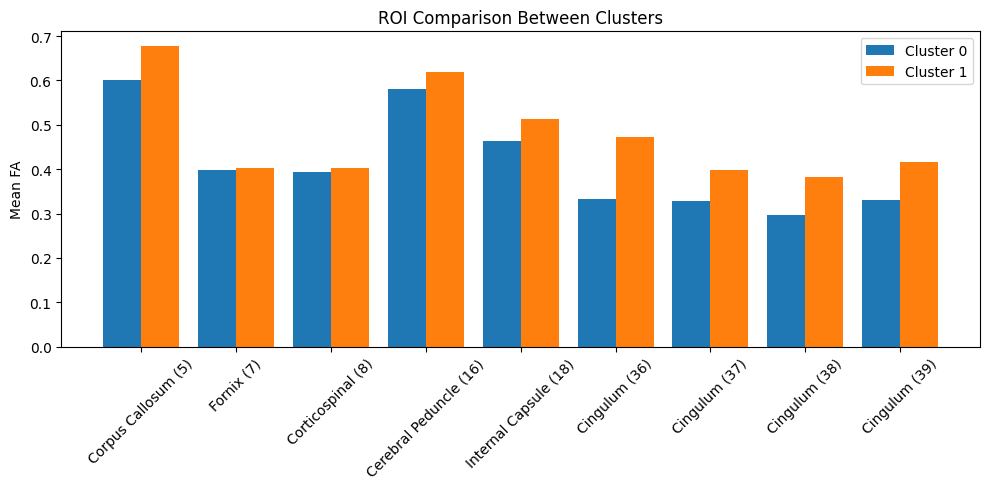

[0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0
 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 1 0 0
 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1
 1 1 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 1
 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1
 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 0 1 1 0
 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0
 1 1 0 1]
[0.99986756 0.99729174 0.9999112  0.9999999  1.         0.9988896
 0.991738   0.9696063  0.9999982  1.         1.         0.97645456
 0.99988115 0.9998951  0.9999999  1.         0.99999976 0.9999974
 0.9999989  0.99999726 0.9987576  0.9999882  0.99999785 0.9986646
 0.9977775  0.99931514 1.         0.5003569  0.99999785 0.9999051
 0.99986565 1.         0.9817624  0.99696714 0.9998209  0.9

In [ ]:
from collections import Counter
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    y_pred = torch.argmax(logits1, dim=1).cpu().numpy()
    y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()

true_labels = y

print("\n===== COMMUNITY LEVEL ANALYSIS =====\n")

cluster_labels = y_pred



for k in range(2):
    idx = (cluster_labels == k)
    print(f"Cluster {k} distribution:", Counter(true_labels[idx]))


num_rois = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)",
    "Fornix (7)",
    "Corticospinal (8)",
    "Cerebral Peduncle (16)",
    "Internal Capsule (18)",
    "Cingulum (36)",
    "Cingulum (37)",
    "Cingulum (38)",
    "Cingulum (39)",
]

roi_indices = {}
for i in range(num_rois):
    roi_indices[roi_names[i]] = (i * bins_per_roi, (i + 1) * bins_per_roi)


bin_edges = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


roi_stats = {}

for roi, (start, end) in roi_indices.items():
    roi_stats[roi] = []

    for k in range(2):
        idx = (cluster_labels == k)

        roi_hist = X[idx, start:end]

        # weighted mean FA
        weighted_mean = (roi_hist * bin_centers).sum(axis=1)

        roi_stats[roi].append(weighted_mean.mean())

print("\nROI Comparison (Cluster 0 vs Cluster 1):\n")

for roi in roi_names:
    c0 = roi_stats[roi][0]
    c1 = roi_stats[roi][1]
    diff = abs(c0 - c1)

    print(f"{roi}: Cluster0={c0:.4f}, Cluster1={c1:.4f}, Diff={diff:.4f}")


roi_importance = sorted(
    [(roi, abs(vals[0] - vals[1])) for roi, vals in roi_stats.items()],
    key=lambda x: x[1],
    reverse=True
)

print("\nMost Important ROIs:\n")
for roi, diff in roi_importance:
    print(f"{roi}: {diff:.4f}")

print("\nStatistical Significance:\n")

for roi, (start, end) in roi_indices.items():

    c0_hist = X[cluster_labels == 0, start:end]
    c1_hist = X[cluster_labels == 1, start:end]

    c0_vals = (c0_hist * bin_centers).sum(axis=1)
    c1_vals = (c1_hist * bin_centers).sum(axis=1)

    stat, p = ttest_ind(c0_vals, c1_vals)

    print(f"{roi}: p-value = {p:.5f}")

roi_means_c0 = [roi_stats[roi][0] for roi in roi_names]
roi_means_c1 = [roi_stats[roi][1] for roi in roi_names]

x = np.arange(len(roi_names))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x + 0.2, roi_means_c1, width=0.4, label="Cluster 1")

plt.xticks(x, roi_names, rotation=45)
plt.ylabel("Mean FA")
plt.title("ROI Comparison Between Clusters")
plt.legend()
plt.tight_layout()
plt.show()


print(y_pred)
print(y_pred_proba.max(axis=-1))

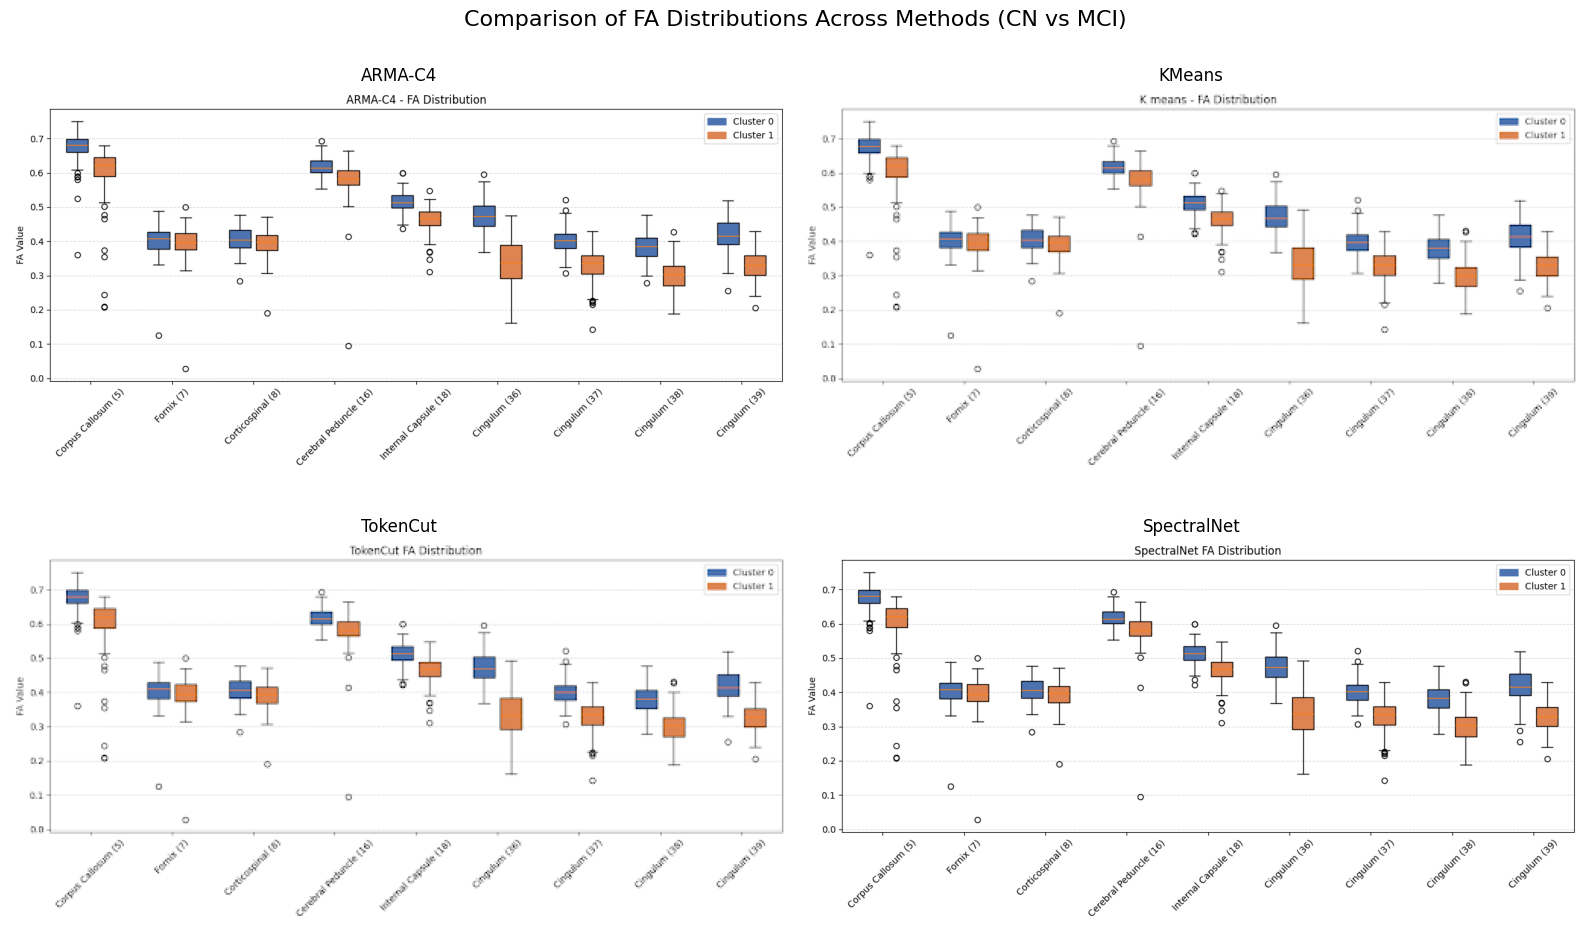

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# File paths
base_path = "/home/snu/Downloads/"

img_arma = mpimg.imread(base_path + "ARMAC4_plot.png")
img_kmeans = mpimg.imread(base_path + "K-means_plot.png")
img_token = mpimg.imread(base_path + "Tokencut_plot.png")
img_spec = mpimg.imread(base_path + "Spectralnet_plot.png")

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot images
axes[0, 0].imshow(img_arma)
axes[0, 0].set_title("ARMA-C4")

axes[0, 1].imshow(img_kmeans)
axes[0, 1].set_title("KMeans")

axes[1, 0].imshow(img_token)
axes[1, 0].set_title("TokenCut")

axes[1, 1].imshow(img_spec)
axes[1, 1].set_title("SpectralNet")

# Remove axes
for ax in axes.flat:
    ax.axis('off')

# Title
plt.suptitle("Comparison of FA Distributions Across Methods (CN vs MCI)", fontsize=16)

plt.tight_layout()
plt.show()